<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/AFM_DPS_50seeds_Foresight_technical_cycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AFM–DPS: 50-сидовый эксперимент с техническим циклом проверки

**Адаптивный сетевой форсайт: гетерогенность, направленные зависимости и устойчивость сложной социально-экономической системы**

Ноутбук повторяет основной AFM–DPS эксперимент на **50 независимых вычислительных репликациях** и добавляет отдельный технический цикл проверки результатов. Вход ограничен двумя файлами:

- `wdi_panel_exel*.xlsx` — World Development Indicators;
- `wgidataset_with_sourcedata-2025*.xlsx` — Worldwide Governance Indicators.

Отдельный файл сетевых данных не используется. Направленная сеть оценивается только из доступной к соответствующему моменту предшествующей динамики WDI/WGI и трактуется как **статистическая сеть прогнозной зависимости**, без причинной интерпретации.

Временная схема сохраняется: 1996–2013 — первичная оценка; 2014–2018 — настройка и техническая калибровка; 2019–2023 — закрытый последовательный тест. Гиперпараметры, калибровка прогнозных интервалов и параметры M3 определяются **до открытия locked test**.

Технический цикл включает четыре дополнительные проверки:

1. **предтестовую conformal-калибровку** 80% и 90% прогнозных интервалов на последовательных прогнозах 2014–2018;
2. шоковый тест с **изменяющейся по годам сетью**, а не с фиксированной матрицей связей в течение всего горизонта;
3. доверительные интервалы рисунков, рассчитанные после **агрегации внутри каждого сида**, чтобы отдельные годы, шоки и origins не интерпретировались как независимые репликации;
4. отдельную таблицу технической приёмки: отсутствие утечки locked test, полнота 50 сидов, конечность seed-level эффектов, уникальность реестра сидов, наличие placebo-сети, корректность динамического shock test и калибровочного контура.

В каждом сиде одновременно варьируются неопределённость WGI, moving-block bootstrap по времени, шоковые направления, численное оценивание оператора устойчивости и placebo-перестройка сети. H1–H6 проверяются критерием Уилкоксона, точным знаковым тестом и sign-flip permutation test; дополнительно выводятся bootstrap-интервалы медиан, оценка Ходжеса–Лемана, рангово-бисериальный размер эффекта и поправка Холма.

**Интерпретация 50 сидов:** это проверка вычислительной устойчивости результатов к предусмотренной измерительной и выборочной неопределённости, а не замена числа независимых стран и лет в исходной панели.

Ноутбук не использует `ipywidgets`, интерактивные JavaScript-виджеты и `xlsxwriter`. Прогресс отображается одной статической полосой `tqdm.std`; итоговые таблицы и графики остаются отображаемыми на GitHub. В ноутбуке подписи даны по-русски. В архиве автоматически создаются отдельные русские и английские Excel-файлы и версии рисунков в PNG, PDF и SVG.


In [1]:

# 1. Среда, зависимости и конфигурация
import os, re, sys, json, math, shutil, zipfile, warnings, logging, platform, subprocess, importlib.util, multiprocessing as mp, gc
from pathlib import Path
from dataclasses import dataclass
from collections import Counter

REQUIRED = {"numpy":"numpy", "pandas":"pandas", "matplotlib":"matplotlib", "sklearn":"scikit-learn", "scipy":"scipy", "openpyxl":"openpyxl", "tqdm":"tqdm"}
missing = [pkg for mod,pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing: subprocess.check_call([sys.executable,"-m","pip","install","-q",*missing])

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import rankdata
from tqdm.std import tqdm
from openpyxl.utils import get_column_letter
from IPython.display import display, Image, Markdown, HTML

warnings.filterwarnings("ignore"); logging.getLogger().setLevel(logging.ERROR)
np.set_printoptions(suppress=True, precision=5)

MASTER_SEED = int(os.environ.get("AFM_MASTER_SEED", "20260923"))
N_SEEDS = int(os.environ.get("AFM_N_SEEDS", "50"))
START_YEAR, TRAIN_END, DEV_END, TEST_END = 1996, 2013, 2018, 2023
MAX_COUNTRIES = int(os.environ.get("AFM_MAX_COUNTRIES", "80"))
FAST_MODE = bool(int(os.environ.get("AFM_FAST_MODE", "0")))

NETWORK_WINDOW, NETWORK_MIN_HISTORY, NETWORK_TOPK, NETWORK_RIDGE = 8, 6, 8, 5.0
SIGMAS = [0,.25,.5,.75,1,1.25,1.5,2]
DELTAS_BASE = [0,.25,.5,.75,1]
DELTAS_SEED = [0,.5,1]
DIMENSIONS = [1,2,4,8]
ALPHAS, HET_LAMBDAS = [.01,.1,1,10,100], [.1,1,10,100]
FTLE_H, SHOCK_H = 3, 5
N_PROBES_BASE, N_PROBES_SEED = 8, 5
POWER_ITERS = 1
N_SHOCKS_BASE, N_SHOCKS_SEED = 100, 36
BLOCK_LENGTH = 3
N_BOOT_SEED = 5000
N_PERM = 20000
MECHANISM_N = 35
INTERVAL_ALPHAS = [.2,.1]
INTERVAL_CALIBRATION = "rolling_conformal_dev"
N_JOBS = int(os.environ.get("AFM_N_JOBS", "2"))
SEED_BATCH_SIZE = int(os.environ.get("AFM_SEED_BATCH_SIZE", "5"))

if FAST_MODE:
    MAX_COUNTRIES = min(MAX_COUNTRIES, 20)
    SIGMAS = [0,.5,1,1.5,2]
    DELTAS_BASE = [0,.5,1]
    DELTAS_SEED = [0,1]
    ALPHAS, HET_LAMBDAS = [.1,1,10], [1,10]
    N_PROBES_BASE, N_PROBES_SEED = 3, 2
    N_SHOCKS_BASE, N_SHOCKS_SEED = 18, 6
    N_BOOT_SEED, N_PERM, MECHANISM_N = 1000, 3000, 18
    NETWORK_TOPK = 5

WDI_BLOCKS = {
 "X1_macro_cycle":["gdp_growth","gdp_pc_growth","inflation","unemployment","gross_capital_form","govt_consumption"],
 "X2_economic_structure":["gdp_pc_usd","exports_gdp","imports_gdp","trade_gdp","fdi_gdp","manufacturing_gdp","nat_resources_gdp"],
 "X3_innovation_digital":["hitech_exports","rd_gdp","researchers_pm","journal_articles","patents_residents","internet_users","mobile_subs","broadband","secure_servers_pm"],
 "X4_human_capital_health":["life_expectancy","infant_mortality","school_secondary","school_tertiary","edu_gdp"],
 "X5_labour_demography":["labor_participation","female_labor","gini_index","pop_growth","urban_pop_pct"],
 "X6_energy_environment":["renewable_energy","electricity_access","energy_use_pc","forest_area_pct"]}
WGI_CANON = ["voice_accountability","political_stability","government_effectiveness","regulatory_quality","rule_of_law","control_corruption"]

IN_COLAB = "google.colab" in sys.modules
INPUT_DIR = Path(os.environ.get("AFM_INPUT_DIR", "/content" if IN_COLAB else "."))
OUTPUT_DIR = Path(os.environ.get("AFM_OUTPUT_DIR", "/content/AFM_DPS_50seeds_technical_results" if IN_COLAB else "./AFM_DPS_50seeds_technical_results"))
FIG_RU, FIG_EN = OUTPUT_DIR/"figures"/"RU", OUTPUT_DIR/"figures"/"EN"
TAB_RU, TAB_EN = OUTPUT_DIR/"tables"/"RU", OUTPUT_DIR/"tables"/"EN"
REP_DIR = OUTPUT_DIR/"reproducibility"
for p in [FIG_RU,FIG_EN,TAB_RU,TAB_EN,REP_DIR]: p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"font.family":"DejaVu Sans","axes.spines.top":False,"axes.spines.right":False})


In [2]:

# 2. Чтение, гармонизация и пространство состояний
ALIASES = {
 "country_code":["country_code","iso3","countrycode","code","economy_code","economy code"],
 "country_name":["country_name","country","economy","name","economy_name","economy name"],
 "year":["year","time","period"], "indicator":["indicator","indicator_name","measure","dimension","governance_dimension","governance dimension"],
 "estimate":["estimate","est","value","score","governance_estimate"], "standard_error":["standard_error","stderr","standard error","se","standard_error_estimate"]}

def normcol(x): return re.sub(r"[^a-z0-9]+","_",str(x).strip().lower()).strip("_")
def alias_find(columns,key):
    d={normcol(c):c for c in columns}
    for a in ALIASES[key]:
        if normcol(a) in d: return d[normcol(a)]
    for c in columns:
        nc=normcol(c)
        if any(normcol(a) in nc or nc in normcol(a) for a in ALIASES[key]): return c
    return None

def canonical_wgi(value):
    n=normcol(value); mp={
      "voice_accountability":["voice_accountability","voice_and_accountability","va"], "political_stability":["political_stability","political_stability_no_violence","pv"],
      "government_effectiveness":["government_effectiveness","ge"], "regulatory_quality":["regulatory_quality","rq"], "rule_of_law":["rule_of_law","rl"],
      "control_corruption":["control_corruption","control_of_corruption","cc"]}
    for k,vv in mp.items():
        if n in vv or any(v==n or (len(v)>2 and v in n) for v in vv): return k
    return n

def discover_input_files(input_dir):
    files=[p for p in list(input_dir.glob("*.xlsx"))+list(input_dir.glob("*.xls")) if not p.name.startswith("~$")]
    def pick(tokens):
        c=[p for p in files if any(t in p.name.lower() for t in tokens)]
        return sorted(c,key=lambda p:("small" in p.name.lower(),len(p.name),p.name))[0] if c else None
    out={"wdi":pick(["wdi_panel_exel","wdi_panel"]),"wgi":pick(["wgidataset_with_sourcedata-2025","wgidataset_with_sourcedata"])}
    if all(out.values()): return out
    if IN_COLAB:
        from google.colab import files as colab_files; colab_files.upload(); return discover_input_files(Path("/content"))
    raise FileNotFoundError("Нужны только два входных файла: wdi_panel_exel*.xlsx и wgidataset_with_sourcedata-2025*.xlsx")

def load_wdi(path):
    xls=pd.ExcelFile(path)
    for sheet in xls.sheet_names:
        head=pd.read_excel(xls,sheet_name=sheet,nrows=5); cc=alias_find(head.columns,"country_code"); yy=alias_find(head.columns,"year")
        if cc and yy:
            df=pd.read_excel(xls,sheet_name=sheet); ren={cc:"country_code",yy:"year"}; cn=alias_find(df.columns,"country_name")
            if cn: ren[cn]="country_name"
            df=df.rename(columns=ren); df.columns=[normcol(c) for c in df.columns]; return df,sheet
    raise ValueError(f"В {path.name} не найден лист WDI с country_code и year")

def load_wgi(path):
    xls=pd.ExcelFile(path); pieces=[]; audit=[]
    for sheet in xls.sheet_names:
        head=pd.read_excel(xls,sheet_name=sheet,nrows=5); fm={k:alias_find(head.columns,k) for k in ["country_code","year","indicator","estimate","standard_error"]}
        if not (fm["country_code"] and fm["year"] and fm["estimate"]): continue
        df=pd.read_excel(xls,sheet_name=sheet); ren={fm["country_code"]:"country_code",fm["year"]:"year",fm["estimate"]:"estimate"}
        if fm["indicator"]: ren[fm["indicator"]]="indicator"
        if fm["standard_error"]: ren[fm["standard_error"]]="standard_error"
        df=df.rename(columns=ren)
        if "indicator" not in df: df["indicator"]=canonical_wgi(sheet)
        if "standard_error" not in df: df["standard_error"]=np.nan
        keep=[c for c in ["country_code","country_name","year","indicator","estimate","standard_error"] if c in df]; df=df[keep].copy()
        df["indicator"]=df["indicator"].map(canonical_wgi); df=df[df.indicator.isin(WGI_CANON)]
        if len(df): pieces.append(df); audit.append({"source":f"WGI:{sheet}","file":path.name,"sheet":sheet,"rows":len(df),"columns":len(df.columns)})
    if not pieces: raise ValueError(f"В {path.name} не распознаны измерения WGI")
    return pd.concat(pieces,ignore_index=True),audit

def load_inputs(paths):
    wdi,ws=load_wdi(paths["wdi"]); wgi,wa=load_wgi(paths["wgi"])
    audit=pd.DataFrame([{"source":"WDI","file":paths["wdi"].name,"sheet":ws,"rows":len(wdi),"columns":wdi.shape[1]},*wa]); return wdi,wgi,audit

def harmonize_inputs(wdi,wgi):
    wdi,wgi=wdi.copy(),wgi.copy(); wdi["year"]=pd.to_numeric(wdi.year,errors="coerce").astype("Int64"); wgi["year"]=pd.to_numeric(wgi.year,errors="coerce").astype("Int64")
    wdi["country_code"]=wdi.country_code.astype(str).str.upper().str.strip(); wgi["country_code"]=wgi.country_code.astype(str).str.upper().str.strip()
    if "country_name" not in wdi: wdi["country_name"]=wdi.country_code
    wgi["indicator"]=wgi.indicator.map(canonical_wgi); wgi["estimate"]=pd.to_numeric(wgi.estimate,errors="coerce"); wgi["standard_error"]=pd.to_numeric(wgi.standard_error,errors="coerce")
    agg={"country_name":"first"}
    for c in wdi.columns:
        if c not in ["country_code","country_name","year"]: wdi[c]=pd.to_numeric(wdi[c],errors="coerce"); agg[c]="mean"
    wdi=wdi.groupby(["country_code","year"],as_index=False).agg(agg)
    wgi=wgi[wgi.indicator.isin(WGI_CANON)].groupby(["country_code","year","indicator"],as_index=False)[["estimate","standard_error"]].mean(); return wdi,wgi

def select_countries_and_window(wdi,wgi):
    y0=max(START_YEAR,int(wdi.year.min()),int(wgi.year.min())); y1=min(TEST_END,int(wdi.year.max()),int(wgi.year.max()))
    if y1<DEV_END+2: raise ValueError(f"Недостаточен временной диапазон: {y0}–{y1}")
    years=list(range(y0,y1+1)); wdi=wdi[wdi.year.between(y0,y1)].copy(); wgi=wgi[wgi.year.between(y0,y1)].copy()
    cols=[c for b in WDI_BLOCKS.values() for c in b if c in wdi.columns]; pre=wdi[wdi.year<=DEV_END]
    wc=pre.groupby("country_code")[cols].apply(lambda x:x.notna().mean().mean()).rename("wdi_coverage")
    wp=wgi[wgi.year<=DEV_END].pivot_table(index=["country_code","year"],columns="indicator",values="estimate")
    for c in WGI_CANON:
        if c not in wp: wp[c]=np.nan
    gc=wp[WGI_CANON].notna().mean(axis=1).groupby("country_code").mean().rename("wgi_coverage")
    cov=pd.concat([wc,gc],axis=1).fillna(0); cov["coverage_score"]=cov.mean(axis=1)
    elig=cov[(cov.wdi_coverage>=.45)&(cov.wgi_coverage>=.50)].sort_values("coverage_score",ascending=False); countries=elig.head(MAX_COUNTRIES).index.tolist()
    if len(countries)<8: raise ValueError(f"После контроля покрытия осталось слишком мало стран: {len(countries)}")
    return wdi,wgi,cov.loc[countries].reset_index(),countries,years

@dataclass
class Projector:
    columns:list; n_components:int; lower:object=None; upper:object=None; median:object=None; mean:object=None; std:object=None; components:object=None; evr:object=None
    def fit(self,df):
        X=df[self.columns].apply(pd.to_numeric,errors="coerce").replace([np.inf,-np.inf],np.nan); self.lower=X.quantile(.01); self.upper=X.quantile(.99); X=X.clip(self.lower,self.upper,axis=1)
        self.median=X.median().fillna(0); X=X.fillna(self.median); self.mean=X.mean(); self.std=X.std(ddof=0).replace(0,1).fillna(1); Z=((X-self.mean)/self.std).to_numpy(float)
        p=PCA(n_components=self.n_components,random_state=MASTER_SEED).fit(Z); comp=p.components_.copy()
        for k in range(comp.shape[0]):
            a=np.argmax(np.abs(comp[k])); comp[k]*=1 if comp[k,a]>=0 else -1
        self.components=comp; self.evr=p.explained_variance_ratio_.copy(); return self
    def transform(self,df):
        X=df.reindex(columns=self.columns).apply(pd.to_numeric,errors="coerce").replace([np.inf,-np.inf],np.nan); X=X.clip(self.lower,self.upper,axis=1).fillna(self.median); return (((X-self.mean)/self.std).to_numpy(float))@self.components.T
    def loadings_df(self,prefix,block):
        return pd.DataFrame([{"component":f"{prefix}{k+1}","variable":c,"loading":float(v),"explained_variance_ratio":float(self.evr[k]),"block":block} for k in range(self.n_components) for c,v in zip(self.columns,self.components[k])])

def make_grid(countries,years,wdi):
    grid=pd.MultiIndex.from_product([countries,years],names=["country_code","year"]).to_frame(index=False); names=wdi.drop_duplicates("country_code").set_index("country_code").country_name.to_dict(); grid["country_name"]=grid.country_code.map(names).fillna(grid.country_code)
    return grid,grid.merge(wdi.drop(columns="country_name"),on=["country_code","year"],how="left")

def build_base_state(wdi,wgi,countries,years):
    grid,wdi_grid=make_grid(countries,years,wdi); state=grid[["country_code","year"]].copy(); projectors={}; loads=[]
    for i,(name,cols0) in enumerate(WDI_BLOCKS.items(),1):
        cols=[c for c in cols0 if c in wdi_grid and wdi_grid.loc[wdi_grid.year<=TRAIN_END,c].notna().any()]
        if len(cols)<2: raise ValueError(f"Блок {name}: менее двух информативных индикаторов")
        pr=Projector(cols,1).fit(wdi_grid[wdi_grid.year<=TRAIN_END]); projectors[name]=pr; state[f"X{i}"]=pr.transform(wdi_grid)[:,0]; loads.append(pr.loadings_df("X",name))
    idx=pd.MultiIndex.from_frame(grid[["country_code","year"]]); we=wgi.pivot_table(index=["country_code","year"],columns="indicator",values="estimate").reindex(idx).reset_index(); we.columns.name=None
    ws=wgi.pivot_table(index=["country_code","year"],columns="indicator",values="standard_error").reindex(idx).reset_index(); ws.columns.name=None
    for c in WGI_CANON:
        if c not in we or we.loc[we.year<=TRAIN_END,c].notna().sum()==0: raise ValueError(f"WGI: отсутствует {c}")
        if c not in ws: ws[c]=np.nan
    wpr=Projector(WGI_CANON,2).fit(we[we.year<=TRAIN_END]); projectors["WGI"]=wpr; sc=wpr.transform(we); state["X7"],state["X8"]=sc[:,0],sc[:,1]; loads.append(wpr.loadings_df("WGI_PC","WGI"))
    cols=[f"X{i}" for i in range(1,9)]; tr=state[state.year<=TRAIN_END][cols]; mean=tr.mean(); std=tr.std(ddof=0).replace(0,1); state[cols]=(state[cols]-mean)/std
    scaling=pd.DataFrame({"component":cols,"train_mean":mean.values,"train_std":std.values}); return grid,wdi_grid,state,we,ws,projectors,pd.concat(loads,ignore_index=True),mean,std,scaling

def sample_state(base_state,wgi_est,wgi_se,wgi_projector,state_mean,state_std,seed):
    rng=np.random.default_rng(seed); samp=wgi_est.copy()
    for c in WGI_CANON:
        mu=pd.to_numeric(wgi_est[c],errors="coerce").to_numpy(float); se=pd.to_numeric(wgi_se[c],errors="coerce").fillna(0).to_numpy(float); samp[c]=mu+rng.normal(size=len(mu))*se
    scores=wgi_projector.transform(samp); s=base_state.copy(); s["X7"]=(scores[:,0]-state_mean["X7"])/state_std["X7"]; s["X8"]=(scores[:,1]-state_mean["X8"])/state_std["X8"]; return s

def state_matrices(state_df,countries,years,qcols=None):
    qcols=qcols or [f"X{i}" for i in range(1,9)]; return {y:state_df[state_df.year==y].set_index("country_code").reindex(countries)[qcols].to_numpy(float) for y in years}


In [3]:

# 3. Сеть, динамические модели M0–M3 и метрики

def _std_time(X):
    X=np.asarray(X,float); mu=X.mean(axis=0,keepdims=True); sd=X.std(axis=0,ddof=0,keepdims=True); sd[sd<1e-8]=1; return (X-mu)/sd

def infer_predictive_networks(state_mats,countries,years):
    N=len(countries); empirical={}; symmetric={}; summary=[]; edges=[]
    for y in years:
        hist=[s for s in years if s<y and (s+1) in state_mats][-NETWORK_WINDOW:]; A=np.zeros((N,N),float)
        if len(hist)>=NETWORK_MIN_HISTORY:
            Xh=np.stack([state_mats[s] for s in hist]); Dh=np.stack([state_mats[s+1]-state_mats[s] for s in hist]); Xstd=_std_time(Xh)
            for i in range(N):
                own=Xh[:,i,:]; target=Dh[:,i,:]; residual=target-Ridge(alpha=NETWORK_RIDGE).fit(own,target).predict(own); residual=_std_time(residual)
                cross=np.einsum("tnq,tr->nqr",Xstd,residual,optimize=True)/max(1,len(hist)-1); scores=np.linalg.norm(cross,axis=(1,2))/max(1,residual.shape[1]); scores[i]=0
                k=min(NETWORK_TOPK,N-1); top=np.argsort(scores)[-k:]; vals=np.clip(scores[top],0,None)
                if vals.sum()>0: A[i,top]=vals/vals.sum()
        np.fill_diagonal(A,0); S=(A+A.T)/2; na,ns=np.linalg.norm(A),np.linalg.norm(S); S=S*(na/ns) if na>0 and ns>0 else S
        empirical[y]=A; symmetric[y]=S; summary.append({"year":y,"nodes":N,"history_transitions":len(hist),"density":np.count_nonzero(A)/max(1,N*(N-1)),"asymmetry_index":np.linalg.norm(A-A.T)/(np.linalg.norm(A)+np.linalg.norm(A.T)+1e-12),"active_rows":int(np.sum(A.sum(1)>0)),"status":"estimated" if len(hist)>=NETWORK_MIN_HISTORY else "insufficient_history"})
        ii,jj=np.where(A>0)
        edges.extend([{"year":y,"target_country":countries[i],"source_country":countries[j],"weight":float(A[i,j])} for i,j in zip(ii,jj)])
    return empirical,symmetric,pd.DataFrame(summary),pd.DataFrame(edges)

def symmetrize_networks(networks):
    out={}
    for y,A in networks.items():
        S=(A+A.T)/2; na,ns=np.linalg.norm(A),np.linalg.norm(S); out[y]=S*(na/ns) if na>0 and ns>0 else S
    return out

def rewire_networks(networks,seed):
    rng=np.random.default_rng(seed); out={}
    for y,A in networks.items():
        B=np.zeros_like(A); N=len(A)
        for i in range(N):
            cols=np.array([j for j in range(N) if j!=i]); vals=A[i,cols].copy(); rng.shuffle(vals); B[i,cols]=vals
        out[y]=B
    return out,symmetrize_networks(out)

def network_at(year,delta,networks,sym_networks):
    A=(1-delta)*sym_networks[year]+delta*networks[year]; nt=np.linalg.norm(networks[year]); nc=np.linalg.norm(A); return A*(nt/nc) if nt>0 and nc>0 else A

def feature_pack(X,A,variant):
    G=np.repeat(X.mean(0,keepdims=True),len(X),axis=0); parts=[X,X*X]; sl={}; o=0; sl["B"]=slice(o,o+X.shape[1]);o+=X.shape[1];sl["R"]=slice(o,o+X.shape[1]);o+=X.shape[1]
    if variant!="M0":
        NBR=A@X; parts += [NBR,X*NBR]; sl["C"]=slice(o,o+X.shape[1]);o+=X.shape[1];sl["Q"]=slice(o,o+X.shape[1]);o+=X.shape[1]
    parts.append(G);sl["G"]=slice(o,o+X.shape[1]); return np.hstack(parts),sl

def build_dataset(state_mats,networks,sym_networks,countries,years,variant,delta=1.0):
    Xs,Ys,owns,meta=[] ,[] ,[] ,[]; slices=None
    for t in years[:-1]:
        if t+1 not in state_mats: continue
        A=network_at(t,delta,networks,sym_networks) if variant!="M0" else np.zeros((len(countries),len(countries))); F,slices=feature_pack(state_mats[t],A,variant); Y=state_mats[t+1]; own=state_mats[t]; mask=np.isfinite(F).all(1)&np.isfinite(Y).all(1)&np.isfinite(own).all(1)
        Xs.append(F[mask]);Ys.append(Y[mask]);owns.append(own[mask]); meta.extend([{"country_code":countries[i],"country_idx":int(i),"origin_year":int(t),"target_year":int(t+1)} for i in np.where(mask)[0]])
    return np.vstack(Xs),np.vstack(Ys),pd.DataFrame(meta),np.vstack(owns),slices

@dataclass
class ModelFit:
    variant:str; alpha:float; hetero_lambda:float; ridge:object; D:np.ndarray; slices:dict; countries:list; q:int; resid_quantiles:dict

def weighted_quantile(x,q,w=None):
    x=np.asarray(x,float); q=np.asarray(q,float)
    if w is None: return np.quantile(x,q)
    w=np.asarray(w,float); m=np.isfinite(x)&np.isfinite(w)&(w>0); x,w=x[m],w[m]
    if len(x)==0: return np.full_like(q,np.nan,dtype=float)
    o=np.argsort(x); x,w=x[o],w[o]; c=np.cumsum(w)-.5*w; c/=w.sum(); return np.interp(q,c,x)

def fit_model(X,Y,meta,own,variant,countries,alpha,hetero_lambda=10,sample_weight=None):
    sw=np.ones(len(Y)) if sample_weight is None else np.asarray(sample_weight,float); ridge=Ridge(alpha=alpha).fit(X,Y,sample_weight=sw); pred=np.atleast_2d(ridge.predict(X)); pred=pred if pred.shape[0]==len(Y) else pred.T; q=Y.shape[1]; D=np.zeros((len(countries),q))
    if variant=="M2":
        res=Y-pred; ci=meta.country_idx.to_numpy(int)
        for c in range(len(countries)):
            m=ci==c
            if m.any():
                for k in range(q):
                    xx,rr,ww=own[m,k],res[m,k],sw[m]; D[c,k]=np.sum(ww*xx*rr)/(np.sum(ww*xx*xx)+hetero_lambda)
        pred=pred+D[ci]*own
    res=Y-pred; rq={}
    for a in [.2,.1]: rq[a]=(np.array([weighted_quantile(res[:,k],[a/2],sw)[0] for k in range(q)]),np.array([weighted_quantile(res[:,k],[1-a/2],sw)[0] for k in range(q)]))
    return ModelFit(variant,alpha,hetero_lambda,ridge,D,{},countries,q,rq)

def predict_fit(fit,X,meta,own):
    p=np.asarray(fit.ridge.predict(X)); p=p.reshape(-1,1) if p.ndim==1 else p
    return p+fit.D[meta.country_idx.to_numpy(int)]*own if fit.variant=="M2" else p

def wis_array(y,p,rq):
    w=.5*np.abs(y-p); den=.5
    for a in [.2,.1]:
        lo,hi=p+rq[a][0],p+rq[a][1]; score=(hi-lo)+(2/a)*(lo-y)*(y<lo)+(2/a)*(y-hi)*(y>hi); w+=(a/2)*score;den+=a/2
    return w/den

def metric_dict(y,p,rq):
    out={"MAE":float(np.mean(np.abs(y-p))),"RMSE":float(np.sqrt(np.mean((y-p)**2))),"WIS":float(np.mean(wis_array(y,p,rq)))}
    for a in INTERVAL_ALPHAS:
        lo,hi=p+rq[a][0],p+rq[a][1];out[f"Coverage{int((1-a)*100)}"]=float(np.mean((y>=lo)&(y<=hi)))
    return out

def choose_hyperparameters(state_mats,networks,sym_networks,countries,years,variant):
    X,Y,m,o,sl=build_dataset(state_mats,networks,sym_networks,countries,years,variant); tr=m.target_year<=TRAIN_END; dv=m.target_year.between(TRAIN_END+1,DEV_END); best=None
    for a in ALPHAS:
        for hl in (HET_LAMBDAS if variant=="M2" else [0.]):
            f=fit_model(X[tr],Y[tr],m[tr].reset_index(drop=True),o[tr],variant,countries,a,hl); p=predict_fit(f,X[dv],m[dv].reset_index(drop=True),o[dv]); sc=float(np.mean(np.abs(Y[dv]-p)))
            if best is None or sc<best["dev_mae"]: best={"variant":variant,"alpha":a,"hetero_lambda":hl,"dev_mae":sc}
    return best,sl

def block_year_count_map(years,end_year,rng,block_length=BLOCK_LENGTH):
    yrs=sorted([int(y) for y in years[1:] if int(y)<=end_year]); n=len(yrs)
    if n<=block_length: return {y:1 for y in yrs}
    starts=list(range(0,n-block_length+1)); draw=[]
    while len(draw)<n:
        s=int(rng.choice(starts)); draw.extend(yrs[s:s+block_length])
    return Counter(draw[:n])

def weights_from_year_map(meta,count_map,end_year):
    return np.array([count_map.get(int(y),1 if int(y)>end_year else 0) for y in meta.target_year],float)

def conformal_quantile(x,coverage):
    x=np.sort(np.asarray(x,float)[np.isfinite(x)])
    if not len(x): return np.nan
    k=min(len(x)-1,max(0,int(math.ceil((len(x)+1)*coverage))-1))
    return float(x[k])

def conformal_rq_from_residuals(residuals):
    R=np.asarray(residuals,float); q=R.shape[1]; out={}
    for a in INTERVAL_ALPHAS:
        cov=1-a; half=np.array([conformal_quantile(np.abs(R[:,k]),cov) for k in range(q)],float); out[a]=(-half,half)
    return out

def rolling_interval_calibration(state_mats,networks,sym_networks,countries,years,variant,hyper,year_weights=None):
    X,Y,m,o,sl=build_dataset(state_mats,networks,sym_networks,countries,years,variant); sw_all=np.ones(len(m)) if year_weights is None else np.asarray(year_weights(m),float); residuals=[]; years_used=[]
    for ty in range(TRAIN_END+1,DEV_END+1):
        hist=m.target_year.to_numpy()<=ty-1; cur=m.target_year.to_numpy()==ty
        if not cur.any() or not hist.any(): continue
        f=fit_model(X[hist],Y[hist],m[hist].reset_index(drop=True),o[hist],variant,countries,hyper["alpha"],hyper["hetero_lambda"],sw_all[hist]); f.slices=sl
        pred=predict_fit(f,X[cur],m[cur].reset_index(drop=True),o[cur]); residuals.append(Y[cur]-pred); years_used.append(ty)
    R=np.vstack(residuals) if residuals else np.empty((0,Y.shape[1])); rq=conformal_rq_from_residuals(R) if len(R) else fit_model(X[m.target_year<=TRAIN_END],Y[m.target_year<=TRAIN_END],m[m.target_year<=TRAIN_END].reset_index(drop=True),o[m.target_year<=TRAIN_END],variant,countries,hyper["alpha"],hyper["hetero_lambda"]).resid_quantiles
    aud={"model":variant,"calibration_start":min(years_used) if years_used else np.nan,"calibration_end":max(years_used) if years_used else np.nan,"calibration_rows":int(len(R)),"calibration_years":len(years_used)}
    if len(R):
        z=np.zeros_like(R); met=metric_dict(R,z,rq); aud.update({"dev_Coverage80":met["Coverage80"],"dev_Coverage90":met["Coverage90"]})
    return rq,aud

def fit_locked_fixed(state_mats,networks,sym_networks,countries,years,hyper_table,year_weights=None,placebo_networks=None,return_calibration=False):
    metrics=[]; pred_by_model={}; fits={}; audits=[]
    for v in ["M0","M1","M2"]:
        nets=placebo_networks[0] if (v=="M1" and placebo_networks is not None) else networks; syms=placebo_networks[1] if (v=="M1" and placebo_networks is not None) else sym_networks
        X,Y,m,o,sl=build_dataset(state_mats,nets,syms,countries,years,v); td=m.target_year<=DEV_END; te=m.target_year.between(DEV_END+1,TEST_END); sw=None if year_weights is None else year_weights(m); h=hyper_table[v]
        rq,aud=rolling_interval_calibration(state_mats,nets,syms,countries,years,v,h,year_weights); audits.append(aud)
        f=fit_model(X[td],Y[td],m[td].reset_index(drop=True),o[td],v,countries,h["alpha"],h["hetero_lambda"],None if sw is None else sw[td]); f.slices=sl; f.resid_quantiles=rq; fits[v]=f
        mt=m[te].reset_index(drop=True); yy=Y[te]; pp=predict_fit(f,X[te],mt,o[te]); row={"model":v,**metric_dict(yy,pp,rq)}; metrics.append(row); pred_by_model[v]=(yy,pp,mt)
    out=(fits,pd.DataFrame(metrics),pred_by_model)
    return (*out,pd.DataFrame(audits)) if return_calibration else out

def residual_matrix(residual,meta,N,q):
    E=np.zeros((N,q)); seen=np.zeros(N,bool)
    for r,ci in enumerate(meta.country_idx.to_numpy(int)): E[ci]=residual[r];seen[ci]=True
    E[~seen]=0;return E

def rank1_residual(E):
    if not np.isfinite(E).all() or np.linalg.norm(E)==0:return np.zeros_like(E),0.
    u,s,vt=np.linalg.svd(E,full_matrices=False);return s[0]*np.outer(u[:,0],vt[0]),float(s[0]**2/np.sum(s**2)) if np.sum(s**2)>0 else 0.

def rolling_m3(state_mats,networks,sym_networks,countries,years,alpha,base_hlam,policy,start_target,end_target,year_weight_func=None,score_start=None,interval_rq=None,return_residuals=False):
    X,Y,m,o,sl=build_dataset(state_mats,networks,sym_networks,countries,years,"M2"); basew=np.ones(len(m)) if year_weight_func is None else year_weight_func(m)
    tr=m.target_year<=TRAIN_END; f0=fit_model(X[tr],Y[tr],m[tr].reset_index(drop=True),o[tr],"M2",countries,alpha,base_hlam,basew[tr]); r0=Y[tr]-predict_fit(f0,X[tr],m[tr].reset_index(drop=True),o[tr]); rms=[]
    for y in sorted(m.loc[tr,"target_year"].unique()): rms.append(np.sqrt(np.mean(r0[m.loc[tr,"target_year"].to_numpy()==y]**2)))
    threshold=float(np.quantile(rms,policy["threshold_q"])); prev_pressure=0.;shock_corr=np.zeros((len(countries),Y.shape[1]));prev_coef=None; all_y=[]; diag=[]
    for ty in range(start_target,end_target+1):
        hist=m.target_year.to_numpy()<=ty-1; cur=m.target_year.to_numpy()==ty
        if not cur.any():continue
        forgetting=float(np.clip(.995-policy["forget_sens"]*prev_pressure,.75,.995));hl=float(np.clip(base_hlam*np.exp(-policy["hetero_sens"]*prev_pressure),base_hlam*.1,base_hlam*5)); age=(ty-1)-m.loc[hist,"target_year"].to_numpy(); w=forgetting**np.maximum(age,0); w*=basew[hist]
        f=fit_model(X[hist],Y[hist],m[hist].reset_index(drop=True),o[hist],"M2",countries,alpha,hl,w);f.slices=sl; cm=m[cur].reset_index(drop=True); act=Y[cur];pred=predict_fit(f,X[cur],cm,o[cur]);pred=pred+policy["shock_decay"]*shock_corr[cm.country_idx.to_numpy(int)] if policy["shock_decay"]>0 else pred
        res=act-pred; E=residual_matrix(res,cm,len(countries),Y.shape[1]); rq_use=interval_rq if interval_rq is not None else f.resid_quantiles; met_y=metric_dict(act,pred,rq_use); rmse=met_y["RMSE"]
        graph=float(np.linalg.norm(networks[ty]-networks[ty-1])/(np.linalg.norm(networks[ty-1])+1e-12)) if ty in networks and ty-1 in networks else 0.; anomaly=rmse/(threshold+1e-12);pressure=max(0,anomaly-1)+.25*graph;rank1,share=rank1_residual(E);active=bool(anomaly>1);shock_corr=rank1 if active else np.zeros_like(E)
        pdri=np.nan if prev_coef is None else float(np.linalg.norm(f.ridge.coef_-prev_coef)/(np.linalg.norm(prev_coef)+1e-12));diag.append({"target_year":ty,"MAE":met_y["MAE"],"RMSE":met_y["RMSE"],"WIS":met_y["WIS"],"Coverage80":met_y["Coverage80"],"Coverage90":met_y["Coverage90"],"anomaly_score":anomaly,"graph_drift":graph,"parameter_drift":pdri,"latent_shock_active":active,"latent_rank1_share":share});all_y.append((ty,act,pred,res));prev_pressure,prev_coef=pressure,f.ridge.coef_.copy()
    score_start=start_target if score_start is None else score_start; scored=[x for x in all_y if x[0]>=score_start]; yy=np.vstack([x[1] for x in scored]); pp=np.vstack([x[2] for x in scored]); rr=np.vstack([x[3] for x in scored]); rq=interval_rq if interval_rq is not None else f0.resid_quantiles; met=metric_dict(yy,pp,rq)
    if return_residuals:return met,pd.DataFrame(diag),rr
    return met,pd.DataFrame(diag)

def calibrate_m3_intervals(state_mats,networks,sym_networks,countries,years,alpha,hlam,policy,year_weight_func=None):
    _,diag,res=rolling_m3(state_mats,networks,sym_networks,countries,years,alpha,hlam,policy,TRAIN_END+1,DEV_END,year_weight_func,score_start=TRAIN_END+1,return_residuals=True); rq=conformal_rq_from_residuals(res); met=metric_dict(res,np.zeros_like(res),rq)
    aud={"model":"M3","calibration_start":TRAIN_END+1,"calibration_end":DEV_END,"calibration_rows":int(len(res)),"calibration_years":int(diag.target_year.nunique()) if len(diag) else 0,"dev_Coverage80":met["Coverage80"],"dev_Coverage90":met["Coverage90"]}
    return rq,aud

def calibrate_m3(state_mats,networks,sym_networks,countries,years,alpha,hlam):
    fg=[0,.04,.08,.12];hg=[0,.25,.5,.75];sg=[0,.15,.3,.45];tg=[.90,.95]
    if FAST_MODE:fg,hg,sg,tg=[0,.08],[0,.5],[0,.25],[.90,.95]
    rows=[];best=None
    for fs in fg:
      for hs in hg:
       for sd in sg:
        for tq in tg:
         pol={"forget_sens":fs,"hetero_sens":hs,"shock_decay":sd,"threshold_q":tq};met,_=rolling_m3(state_mats,networks,sym_networks,countries,years,alpha,hlam,pol,TRAIN_END+1,DEV_END);loss=met["MAE"];rows.append({**pol,"dev_mae":loss});best=(loss,pol.copy()) if best is None or loss<best[0] else best
    return best[1],pd.DataFrame(rows).sort_values("dev_mae").reset_index(drop=True)


In [4]:

# 4. Устойчивость, шоки, редукция размерности и механизм

def unpack_m2(fit):
    c=np.atleast_2d(fit.ridge.coef_);sl=fit.slices;q=fit.q;z=np.zeros((q,q));return {"B":c[:,sl["B"]],"R":c[:,sl["R"]],"C":c[:,sl["C"]] if "C" in sl else z,"Q":c[:,sl["Q"]] if "Q" in sl else z,"G":c[:,sl["G"]]}
def D_at_sigma(D,sigma):
    m=D.mean(0,keepdims=True);return m+sigma*(D-m)
def jv_batch(V,X,A,par,Dsig):
    nbrV=np.einsum("ij,jqk->iqk",A,V,optimize=True);nbrX=A@X;out=np.einsum("njk,oj->nok",V,par["B"],optimize=True)+Dsig[:,:,None]*V;out+=np.einsum("njk,oj->nok",2*X[:,:,None]*V,par["R"],optimize=True);out+=np.einsum("njk,oj->nok",nbrV,par["C"],optimize=True);qin=V*nbrX[:,:,None]+X[:,:,None]*nbrV;out+=np.einsum("njk,oj->nok",qin,par["Q"],optimize=True);g=np.einsum("jk,oj->ok",V.mean(0),par["G"],optimize=True);return out+g[None,:,:]
def jtv_batch(W,X,A,par,Dsig):
    nbrX=A@X;out=np.einsum("nok,oj->njk",W,par["B"],optimize=True)+Dsig[:,:,None]*W;rr=np.einsum("nok,oj->njk",W,par["R"],optimize=True);out+=2*X[:,:,None]*rr;cc=np.einsum("nok,oj->njk",W,par["C"],optimize=True);out+=np.einsum("ji,jqk->iqk",A,cc,optimize=True);qq=np.einsum("nok,oj->njk",W,par["Q"],optimize=True);out+=nbrX[:,:,None]*qq+np.einsum("ji,jqk->iqk",A,X[:,:,None]*qq,optimize=True);gg=np.einsum("nok,oj->jk",W,par["G"],optimize=True)/len(X);return out+gg[None,:,:]

def estimate_operator_norm(origin,horizon,sigma,delta,state_mats,networks,sym_networks,fit,probes,seed):
    N,q=state_mats[origin].shape;dim=N*q;k=min(probes,dim);rng=np.random.default_rng(np.random.SeedSequence([int(seed),int(origin),int(horizon)]));Q,_=np.linalg.qr(rng.normal(size=(dim,k)));par=unpack_m2(fit);Ds=D_at_sigma(fit.D,sigma)
    def fwd(Qf):
        V=Qf.reshape(N,q,k)
        for y in range(origin,origin+horizon):V=jv_batch(V,state_mats[y],network_at(y,delta,networks,sym_networks),par,Ds)
        return V.reshape(dim,k)
    def adj(Yf):
        W=Yf.reshape(N,q,k)
        for y in reversed(range(origin,origin+horizon)):W=jtv_batch(W,state_mats[y],network_at(y,delta,networks,sym_networks),par,Ds)
        return W.reshape(dim,k)
    for _ in range(POWER_ITERS):Q,_=np.linalg.qr(adj(fwd(Q)))
    return float(np.linalg.svd(fwd(Q),compute_uv=False)[0])

def stability_landscape(state_mats,networks,sym_networks,fit,years,sigmas,deltas,H,probes,seed):
    origins=[y for y in range(DEV_END+1,max(years)-H+2) if all((y+h) in state_mats for h in range(H))];rows=[]
    for s in sigmas:
      for d in deltas:
       for o in origins:
        norms=[estimate_operator_norm(o,h,s,d,state_mats,networks,sym_networks,fit,probes,seed) for h in range(1,H+1)];rows.append({"sigma":s,"delta":d,"origin_year":o,"H":H,"operator_norm_H":norms[-1],"ftle":float(np.log(max(norms[-1],1e-12))/H),"transient_gain":float(max(norms))})
    z=pd.DataFrame(rows);base=z[z.sigma==0][["delta","origin_year","ftle"]].rename(columns={"ftle":"ftle_sigma0"});z=z.merge(base,on=["delta","origin_year"]);z["delta_ftle_vs_sigma0"]=z.ftle-z.ftle_sigma0;return z

def predict_state(X,A,fit,sigma):
    F,_=feature_pack(X,A,"M2");return np.clip(np.nan_to_num(fit.ridge.predict(F)+D_at_sigma(fit.D,sigma)*X,nan=0,posinf=20,neginf=-20),-20,20)

def dev_residuals_oos(state_mats,networks,sym_networks,countries,years,hyper,year_weight_func=None):
    X,Y,m,o,sl=build_dataset(state_mats,networks,sym_networks,countries,years,"M2");tr=m.target_year<=TRAIN_END;dv=m.target_year.between(TRAIN_END+1,DEV_END);sw=np.ones(len(m)) if year_weight_func is None else year_weight_func(m);f=fit_model(X[tr],Y[tr],m[tr].reset_index(drop=True),o[tr],"M2",countries,hyper["alpha"],hyper["hetero_lambda"],sw[tr]);f.slices=sl;p=predict_fit(f,X[dv],m[dv].reset_index(drop=True),o[dv]);return Y[dv]-p

def create_shock_library(residuals,N,q,A,n_shocks,seed):
    rng=np.random.default_rng(seed);local=residuals.reshape(-1,q);local=local[np.isfinite(local).all(1)];S=(A+A.T)/2;out=[]
    for r in range(n_shocks):
        typ=["global","community","node"][r%3];direction=local[rng.integers(len(local))].copy();shock=np.zeros((N,q))
        if typ=="global":shock[:]=direction
        elif typ=="node":shock[rng.integers(N)]=direction
        else:
            i=rng.integers(N);nb=np.argsort(S[i])[-max(2,N//5):];shock[nb]=direction
        n=np.linalg.norm(shock);out.append((typ,shock/n if n>0 else shock))
    return out

def shock_experiment(state_mats,networks,sym_networks,fit,origin,sigmas,deltas,residuals,H,n_shocks,seed,dynamic_network=True):
    H_eff=min(H,max(state_mats)-origin); lib=create_shock_library(residuals,len(fit.countries),fit.q,networks[origin],n_shocks,seed);rows=[]
    for s in sigmas:
      for d in deltas:
       X0=state_mats[origin];base=[X0]
       for h in range(1,H_eff+1):
        y=origin+h-1;A=network_at(y,d,networks,sym_networks) if dynamic_network else network_at(origin,d,networks,sym_networks);base.append(predict_state(base[-1],A,fit,s))
       for sid,(typ,shock) in enumerate(lib):
        cur=X0+shock;dev=[]
        for h in range(1,H_eff+1):
         y=origin+h-1;A=network_at(y,d,networks,sym_networks) if dynamic_network else network_at(origin,d,networks,sym_networks);cur=predict_state(cur,A,fit,s);dev.append(float(np.linalg.norm(cur-base[h])))
        rec=next((h for h,v in enumerate(dev,1) if v<=.25),H_eff+1);rows.append({"sigma":s,"delta":d,"shock_id":sid,"shock_type":typ,"origin_year":origin,"H":H_eff,"network_mode":"dynamic" if dynamic_network else "fixed_origin","impact_depth":max(dev),"cumulative_deviation":sum(dev),"recovery_time":rec})
    z=pd.DataFrame(rows);b=z[z.sigma==0][["delta","shock_id","cumulative_deviation"]].rename(columns={"cumulative_deviation":"cumdev_sigma0"});z=z.merge(b,on=["delta","shock_id"]);z["delta_cumdev_vs_sigma0"]=z.cumulative_deviation-z.cumdev_sigma0;return z

def shock_network_control(state_mats,networks,sym_networks,fit,origin,residuals,H,n_shocks,seed):
    dyn=shock_experiment(state_mats,networks,sym_networks,fit,origin,[0,1],[1],residuals,H,n_shocks,seed,True);fix=shock_experiment(state_mats,networks,sym_networks,fit,origin,[0,1],[1],residuals,H,n_shocks,seed,False);z=pd.concat([dyn,fix],ignore_index=True)
    return z.groupby(["network_mode","sigma"],as_index=False).agg(mean_cumdev=("cumulative_deviation","mean"),median_cumdev=("cumulative_deviation","median"),mean_impact=("impact_depth","mean"),median_recovery=("recovery_time","median"))

def reduce_state(state_df,q):
    if q==8:return state_df[["country_code","year"]+[f"X{i}" for i in range(1,9)]].copy()
    cols=[f"X{i}" for i in range(1,9)];tr=state_df[state_df.year<=TRAIN_END][cols];mu=tr.mean();sd=tr.std(ddof=0).replace(0,1);p=PCA(n_components=q,random_state=MASTER_SEED).fit(((tr-mu)/sd).to_numpy(float));sc=p.transform(((state_df[cols]-mu)/sd).to_numpy(float));out=state_df[["country_code","year"]].copy()
    for k in range(q):out[f"X{k+1}"]=sc[:,k]
    return out

def dimension_hyperparameters(base_state,networks,sym_networks,countries,years):
    rows=[]
    for q in DIMENSIONS:
        rs=reduce_state(base_state,q);mats=state_matrices(rs,countries,years,[f"X{i}" for i in range(1,q+1)]);best,_=choose_hyperparameters(mats,networks,sym_networks,countries,years,"M2");rows.append({"q":q,**best})
    return pd.DataFrame(rows)

def dimension_seed_effect(state_df,networks,sym_networks,countries,years,dim_hyper,year_weight_func,seed):
    rows=[]
    for q in DIMENSIONS:
        rs=reduce_state(state_df,q);mats=state_matrices(rs,countries,years,[f"X{i}" for i in range(1,q+1)]);X,Y,m,o,sl=build_dataset(mats,networks,sym_networks,countries,years,"M2");td=m.target_year<=DEV_END;sw=year_weight_func(m);h=dim_hyper.set_index("q").loc[q];f=fit_model(X[td],Y[td],m[td].reset_index(drop=True),o[td],"M2",countries,h.alpha,h.hetero_lambda,sw[td]);f.slices=sl;land=stability_landscape(mats,networks,sym_networks,f,years,[0,1],[1],FTLE_H,N_PROBES_SEED,seed);eff=float(land[land.sigma==1].delta_ftle_vs_sigma0.mean());rows.append({"q":q,"delta_ftle_sigma1":eff})
    return pd.DataFrame(rows)

def dimension_baseline_experiment(state_df,networks,sym_networks,countries,years,dim_hyper,seed):
    rows=[]
    for q in DIMENSIONS:
        rs=reduce_state(state_df,q);mats=state_matrices(rs,countries,years,[f"X{i}" for i in range(1,q+1)]);X,Y,m,o,sl=build_dataset(mats,networks,sym_networks,countries,years,"M2");td=m.target_year<=DEV_END;h=dim_hyper.set_index("q").loc[q];f=fit_model(X[td],Y[td],m[td].reset_index(drop=True),o[td],"M2",countries,h.alpha,h.hetero_lambda);f.slices=sl;land=stability_landscape(mats,networks,sym_networks,f,years,SIGMAS,DELTAS_BASE,FTLE_H,N_PROBES_BASE,seed+q);land["q"]=q;rows.append(land)
    return pd.concat(rows,ignore_index=True)

def explicit_jacobian(X,A,fit,sigma):
    N,q=X.shape;dim=N*q;I=np.eye(dim).reshape(N,q,dim);return jv_batch(I,X,A,unpack_m2(fit),D_at_sigma(fit.D[:N],sigma)).reshape(dim,dim)
def mechanism_diagnostics(state_mats,networks,sym_networks,fit,countries,origin):
    n=min(MECHANISM_N,len(countries));idx=np.arange(n);rows=[]
    for d in [0,1]:
      Af=network_at(origin,d,networks,sym_networks);A=Af[np.ix_(idx,idx)];X=state_mats[origin][idx];sub=ModelFit(fit.variant,fit.alpha,fit.hetero_lambda,fit.ridge,fit.D[idx],fit.slices,[countries[i] for i in idx],fit.q,fit.resid_quantiles)
      for s in [0,1]:
        J=explicit_jacobian(X,A,sub,s);eig=np.linalg.eigvals(J);rho=float(np.max(np.abs(eig)));non=float(np.linalg.norm(J@J.T-J.T@J,"fro")/(np.linalg.norm(J,"fro")**2+1e-12));rows.append({"delta":d,"sigma":s,"spectral_radius":rho,"nonnormality":non,"max_real_eigenvalue":float(np.max(eig.real))})
    return pd.DataFrame(rows)


In [5]:

# 5. Непараметрическая статистика, экспорт и двуязычная визуализация

def holm_adjust(pvals):
    p=np.asarray(pvals,float);m=len(p);o=np.argsort(p);adj=np.empty(m);running=0
    vals=np.minimum(1,(m-np.arange(m))*p[o]);vals=np.maximum.accumulate(vals);adj[o]=vals;return adj

def hodges_lehmann(x):
    x=np.asarray(x,float);x=x[np.isfinite(x)];w=(x[:,None]+x[None,:])/2;return float(np.median(w[np.triu_indices(len(x))])) if len(x) else np.nan

def rank_biserial_1samp(x):
    x=np.asarray(x,float);x=x[np.isfinite(x)&(x!=0)]
    if not len(x):return np.nan
    r=rankdata(np.abs(x));return float((r[x>0].sum()-r[x<0].sum())/r.sum())

def bootstrap_ci(x,stat=np.median,n_boot=N_BOOT_SEED,seed=MASTER_SEED):
    x=np.asarray(x,float);x=x[np.isfinite(x)]
    if not len(x):return (np.nan,np.nan,np.nan)
    rng=np.random.default_rng(seed);idx=rng.integers(0,len(x),size=(n_boot,len(x)));bs=np.apply_along_axis(stat,1,x[idx]);return float(stat(x)),float(np.quantile(bs,.025)),float(np.quantile(bs,.975))

def wilcoxon_safe(x,alternative="two-sided"):
    x=np.asarray(x,float);x=x[np.isfinite(x)&(x!=0)]
    if not len(x):return np.nan,1.0
    try:r=stats.wilcoxon(x,alternative=alternative,zero_method="wilcox",method="auto");return float(r.statistic),float(r.pvalue)
    except:return np.nan,1.0

def sign_test(x,alternative="two-sided"):
    x=np.asarray(x,float);x=x[np.isfinite(x)&(x!=0)];pos=int((x>0).sum());n=len(x)
    if not n:return 1.0
    return float(stats.binomtest(pos,n,.5,alternative=alternative).pvalue)

def signflip_test(x,alternative="two-sided",n_perm=N_PERM,seed=MASTER_SEED):
    x=np.asarray(x,float);x=x[np.isfinite(x)];obs=float(np.mean(x));rng=np.random.default_rng(seed);sim=[]
    batch=1000
    for st in range(0,n_perm,batch):
        b=min(batch,n_perm-st);sg=rng.choice([-1.,1.],size=(b,len(x)));sim.append((sg*x).mean(1))
    sim=np.concatenate(sim)
    if alternative=="less":p=(1+np.sum(sim<=obs))/(len(sim)+1)
    elif alternative=="greater":p=(1+np.sum(sim>=obs))/(len(sim)+1)
    else:p=(1+np.sum(np.abs(sim)>=abs(obs)))/(len(sim)+1)
    return float(p)

def wilson_interval(k,n,z=1.95996398454):
    if n==0:return np.nan,np.nan
    p=k/n;den=1+z*z/n;center=(p+z*z/(2*n))/den;half=z*math.sqrt(p*(1-p)/n+z*z/(4*n*n))/den;return center-half,center+half

def inference_row(code,label,x,alternative,seed,expected=None):
    x=np.asarray(x,float);x=x[np.isfinite(x)];med,lo,hi=bootstrap_ci(x,np.median,seed=seed);W,pw=wilcoxon_safe(x,alternative);W2,pw2=wilcoxon_safe(x,"two-sided");ps=sign_test(x,alternative);ps2=sign_test(x,"two-sided");pp=signflip_test(x,alternative,seed=seed+17);pp2=signflip_test(x,"two-sided",seed=seed+117);rb=rank_biserial_1samp(x);pos=int((x>0).sum());neg=int((x<0).sum());n=pos+neg
    if expected=="negative":support=neg
    elif expected=="positive":support=pos
    else:support=max(pos,neg)
    wl,wh=wilson_interval(support,n)
    return {"hypothesis":code,"estimand":label,"n_seeds":len(x),"mean":float(np.mean(x)),"median":med,"sd":float(np.std(x,ddof=1)),"iqr":float(np.subtract(*np.percentile(x,[75,25]))),"hodges_lehmann":hodges_lehmann(x),"ci95_median_low":lo,"ci95_median_high":hi,"wilcoxon_W":W,"p_wilcoxon":pw,"p_wilcoxon_two_sided":pw2,"p_sign":ps,"p_sign_two_sided":ps2,"p_permutation":pp,"p_permutation_two_sided":pp2,"rank_biserial":rb,"positive_seeds":pos,"negative_seeds":neg,"support_share":support/n if n else np.nan,"support_ci_low":wl,"support_ci_high":wh,"alternative":alternative}

def seed_inference(seed_effects):
    rows=[]
    rows.append(inference_row("H1","M1−M0: MAE",seed_effects.h1_m1_m0_mae,"less",MASTER_SEED+1,"negative"))
    r2a=inference_row("H2a","ΔFTLE(σ=1, δ=1)",seed_effects.h2_ftle_sigma1,"less",MASTER_SEED+2,"negative");r2b=inference_row("H2b","ΔCumDev(σ=1, δ=1)",seed_effects.h2_cumdev_sigma1,"less",MASTER_SEED+3,"negative");rows += [r2a,r2b]
    rows.append(inference_row("H3","Квадратичная кривизна S(σ)",seed_effects.h3_quadratic_coef,"two-sided",MASTER_SEED+4,None))
    rows.append(inference_row("H4","Эффект q=8 минус q=1",seed_effects.h4_q8_minus_q1,"two-sided",MASTER_SEED+5,None))
    rows.append(inference_row("H5","Взаимодействие направленности",seed_effects.h5_direction_interaction,"two-sided",MASTER_SEED+6,None))
    rows.append(inference_row("H6","M3−M2: MAE",seed_effects.h6_m3_m2_mae,"less",MASTER_SEED+7,"negative"))
    rows.append(inference_row("H1-placebo","M1−M1(placebo): MAE",seed_effects.h1_placebo_mae,"less",MASTER_SEED+8,"negative"))
    inf=pd.DataFrame(rows)
    p_h2=max(float(r2a["p_wilcoxon"]),float(r2b["p_wilcoxon"]))
    primary=pd.DataFrame([
      {"hypothesis":"H1","p_primary":float(inf.loc[inf.hypothesis=="H1","p_wilcoxon"].iloc[0])},
      {"hypothesis":"H2","p_primary":p_h2},
      {"hypothesis":"H3","p_primary":float(inf.loc[inf.hypothesis=="H3","p_wilcoxon"].iloc[0])},
      {"hypothesis":"H4","p_primary":float(inf.loc[inf.hypothesis=="H4","p_wilcoxon"].iloc[0])},
      {"hypothesis":"H5","p_primary":float(inf.loc[inf.hypothesis=="H5","p_wilcoxon"].iloc[0])},
      {"hypothesis":"H6","p_primary":float(inf.loc[inf.hypothesis=="H6","p_wilcoxon"].iloc[0])}])
    primary["p_holm"]=holm_adjust(primary.p_primary.to_numpy());primary["significant_holm_0_05"]=primary.p_holm<.05
    joint=(seed_effects.h2_ftle_sigma1<0)&(seed_effects.h2_cumdev_sigma1<0);jl,jh=wilson_interval(int(joint.sum()),len(joint));primary.loc[primary.hypothesis=="H2","joint_negative_share"]=joint.mean();primary.loc[primary.hypothesis=="H2","joint_share_ci_low"]=jl;primary.loc[primary.hypothesis=="H2","joint_share_ci_high"]=jh
    return inf,primary

def friedman_pairwise(seed_model_metrics):
    w=seed_model_metrics.pivot(index="seed_id",columns="model",values="MAE")[["M0","M1","M2","M3"]].dropna();fr=stats.friedmanchisquare(*[w[c] for c in w.columns]);global_tbl=pd.DataFrame([{"test":"Friedman MAE M0–M3","n_seeds":len(w),"statistic":float(fr.statistic),"p_value":float(fr.pvalue),"kendalls_W":float(fr.statistic/(len(w)*(len(w.columns)-1))) }])
    prs=[]
    cols=list(w.columns)
    for i in range(len(cols)):
      for j in range(i+1,len(cols)):
       d=w[cols[i]]-w[cols[j]];W,p=wilcoxon_safe(d,"two-sided");prs.append({"model_A":cols[i],"model_B":cols[j],"median_MAE_diff_A_minus_B":float(np.median(d)),"wilcoxon_W":W,"p_raw":p,"rank_biserial":rank_biserial_1samp(d)})
    pair=pd.DataFrame(prs);pair["p_holm"]=holm_adjust(pair.p_raw.to_numpy());return global_tbl,pair

def convergence_table(seed_effects):
    rows=[]
    specs={"H1":("h1_m1_m0_mae","negative"),"H2_FTLE":("h2_ftle_sigma1","negative"),"H2_Shock":("h2_cumdev_sigma1","negative"),"H4":("h4_q8_minus_q1",None),"H5":("h5_direction_interaction",None),"H6":("h6_m3_m2_mae","negative")}
    for k in [10,20,30,40,50]:
      if k>len(seed_effects):continue
      sub=seed_effects.iloc[:k]
      for lab,(col,direction) in specs.items():
       x=sub[col].to_numpy(float);pos=(x>0).sum();neg=(x<0).sum();support=neg if direction=="negative" else max(pos,neg);rows.append({"seeds_used":k,"effect":lab,"median":float(np.median(x)),"mean":float(np.mean(x)),"support_share":support/max(1,pos+neg)})
    return pd.DataFrame(rows)


def run_seed_batch(seed_items, ctx):
    """Изолированный пакет seed-репликаций; внутри пакета нет вывода."""
    out={"model":[],"stability":[],"shocks":[],"dimensions":[],"effects":[],"network":[],"calibration":[]}
    for sid,seed in seed_items:
        rng=np.random.default_rng(seed);sstate=sample_state(ctx["state"],ctx["wgi_est"],ctx["wgi_se"],ctx["wgi_projector"],ctx["state_mean"],ctx["state_std"],seed);smats=state_matrices(sstate,ctx["countries"],ctx["years"]);snets,ssyms,snet_summary,_=infer_predictive_networks(smats,ctx["countries"],ctx["years"])
        year_counts=block_year_count_map(ctx["years"],DEV_END,rng,BLOCK_LENGTH);year_weight_func=lambda meta,wc=year_counts:weights_from_year_map(meta,wc,DEV_END)
        sfits,smetrics,_,cal=fit_locked_fixed(smats,snets,ssyms,ctx["countries"],ctx["years"],ctx["hyper_table"],year_weight_func,return_calibration=True);smetrics["seed_id"]=sid;smetrics["seed"]=seed;out["model"].append(smetrics);cal["seed_id"]=sid;cal["seed"]=seed;out["calibration"].append(cal)
        m3rq,m3ca=calibrate_m3_intervals(smats,snets,ssyms,ctx["countries"],ctx["years"],ctx["hyper_table"]["M2"]["alpha"],ctx["hyper_table"]["M2"]["hetero_lambda"],ctx["m3_policy"],year_weight_func);m3ca.update({"seed_id":sid,"seed":seed});out["calibration"].append(pd.DataFrame([m3ca]));m3met,_=rolling_m3(smats,snets,ssyms,ctx["countries"],ctx["years"],ctx["hyper_table"]["M2"]["alpha"],ctx["hyper_table"]["M2"]["hetero_lambda"],ctx["m3_policy"],TRAIN_END+1,TEST_END,year_weight_func,score_start=DEV_END+1,interval_rq=m3rq);out["model"].append(pd.DataFrame([{"model":"M3","seed_id":sid,"seed":seed,**m3met}]))
        pnet,psym=rewire_networks(snets,seed+101);_,pmetric,_=fit_locked_fixed(smats,snets,ssyms,ctx["countries"],ctx["years"],ctx["hyper_table"],year_weight_func,placebo_networks=(pnet,psym));pm=pmetric[pmetric.model=="M1"].copy();pm["model"]="M1_placebo";pm["seed_id"]=sid;pm["seed"]=seed;out["model"].append(pm)
        sf=sfits["M2"];sf.slices=ctx["feature_slices_M2"];land=stability_landscape(smats,snets,ssyms,sf,ctx["years"],SIGMAS,DELTAS_SEED,FTLE_H,N_PROBES_SEED,seed);land["seed_id"]=sid;land["seed"]=seed;out["stability"].append(land)
        dres=dev_residuals_oos(smats,snets,ssyms,ctx["countries"],ctx["years"],ctx["hyper_table"]["M2"],year_weight_func);shr=shock_experiment(smats,snets,ssyms,sf,ctx["shock_origin"],SIGMAS,[1],dres,SHOCK_H,N_SHOCKS_SEED,seed+202,True);shr["seed_id"]=sid;shr["seed"]=seed;out["shocks"].append(shr)
        dr=dimension_seed_effect(sstate,snets,ssyms,ctx["countries"],ctx["years"],ctx["dim_hyper"],year_weight_func,seed+303);dr["seed_id"]=sid;dr["seed"]=seed;out["dimensions"].append(dr)
        mm=pd.concat([smetrics,pd.DataFrame([{"model":"M3",**m3met}]),pm],ignore_index=True).set_index("model");lmean=land.groupby(["sigma","delta"]).delta_ftle_vs_sigma0.mean();curve=land[land.delta==1].groupby("sigma").delta_ftle_vs_sigma0.mean().reindex(SIGMAS);quad=float(np.polyfit(np.asarray(SIGMAS,float),curve.to_numpy(float),2)[0]);dw=dr.set_index("q").delta_ftle_sigma1
        out["effects"].append({"seed_id":sid,"seed":seed,"h1_m1_m0_mae":float(mm.loc["M1","MAE"]-mm.loc["M0","MAE"]),"h1_placebo_mae":float(mm.loc["M1","MAE"]-mm.loc["M1_placebo","MAE"]),"h2_ftle_sigma1":float(lmean.loc[(1,1)]),"h2_cumdev_sigma1":float(shr[shr.sigma==1].delta_cumdev_vs_sigma0.mean()),"h3_quadratic_coef":quad,"h4_q8_minus_q1":float(dw.loc[8]-dw.loc[1]),"h5_direction_interaction":float(lmean.loc[(1,1)]-lmean.loc[(1,0)]),"h6_m3_m2_mae":float(mm.loc["M3","MAE"]-mm.loc["M2","MAE"])})
        out["network"].append({"seed_id":sid,"seed":seed,"mean_density":float(snet_summary.loc[snet_summary.status=="estimated","density"].mean()),"mean_asymmetry":float(snet_summary.loc[snet_summary.status=="estimated","asymmetry_index"].mean())})
    return out

def run_seed_batch_star(args):
    batch,ctx=args
    return run_seed_batch(batch,ctx)

RU_COLS={
"seed_id":"Сид №","seed":"Сид","model":"Модель","variant":"Вариант модели","model_A":"Модель A","model_B":"Модель B","MAE":"MAE","RMSE":"RMSE","WIS":"WIS","Coverage80":"Покрытие 80%","Coverage90":"Покрытие 90%","MAE_mean":"Среднее MAE","MAE_median":"Медиана MAE","MAE_sd":"SD MAE","RMSE_median":"Медиана RMSE","WIS_median":"Медиана WIS","Coverage80_median":"Медиана покрытия 80%","Coverage90_median":"Медиана покрытия 90%",
"hypothesis":"Гипотеза","estimand":"Оцениваемый эффект","n_seeds":"Число сидов","mean":"Среднее","median":"Медиана","sd":"Станд. отклонение","iqr":"Межкварт. размах","hodges_lehmann":"Оценка Ходжеса–Лемана","ci95_median_low":"95% ДИ медианы: нижняя","ci95_median_high":"95% ДИ медианы: верхняя","wilcoxon_W":"Статистика Уилкоксона","p_wilcoxon":"p Уилкоксона (направленный)","p_wilcoxon_two_sided":"p Уилкоксона (двусторонний)","p_sign":"p знакового теста (направленный)","p_sign_two_sided":"p знакового теста (двусторонний)","p_permutation":"p sign-flip permutation (направленный)","p_permutation_two_sided":"p sign-flip permutation (двусторонний)","rank_biserial":"Рангово-бисериальный эффект","positive_seeds":"Сиды с положительным знаком","negative_seeds":"Сиды с отрицательным знаком","support_share":"Доля согласованных сидов","support_ci_low":"ДИ доли: нижняя","support_ci_high":"ДИ доли: верхняя","alternative":"Альтернатива","p_primary":"Основное p","p_holm":"p после Холма","significant_holm_0_05":"Значимо после Холма (0,05)","joint_negative_share":"Доля сидов с двумя отрицательными эффектами","joint_share_ci_low":"ДИ совместной доли: нижняя","joint_share_ci_high":"ДИ совместной доли: верхняя",
"sigma":"σ","delta":"δ","q":"Размерность q","H":"Горизонт H","delta_ftle_vs_sigma0":"ΔFTLE к σ=0","delta_ftle_sigma1":"ΔFTLE при σ=1","delta_cumdev_vs_sigma0":"Δ накопленного отклонения к σ=0","ftle":"FTLE","ftle_sigma0":"FTLE при σ=0","operator_norm_H":"Норма оператора на горизонте H","transient_gain":"Переходное усиление","impact_depth":"Максимальная глубина отклонения","cumulative_deviation":"Накопленное отклонение","cumdev_sigma0":"Накопленное отклонение при σ=0","recovery_time":"Время восстановления","shock_id":"ID возмущения","shock_type":"Тип возмущения","origin_year":"Год начала",
"source":"Источник","file":"Файл","sheet":"Лист","rows":"Строки","columns":"Столбцы","country_code":"Код страны","year":"Год","wdi_coverage":"Покрытие WDI","wgi_coverage":"Покрытие WGI","coverage_score":"Итоговое покрытие","component":"Компонента","variable":"Переменная","loading":"Нагрузка","explained_variance_ratio":"Доля объяснённой дисперсии","block":"Блок","train_mean":"Среднее train","train_std":"SD train",
"nodes":"Число узлов","history_transitions":"Исторические переходы","density":"Плотность","asymmetry_index":"Индекс асимметрии","active_rows":"Активные строки","status":"Статус","target_country":"Страна-цель","source_country":"Страна-источник","weight":"Вес","mean_density":"Средняя плотность","mean_asymmetry":"Средняя асимметрия",
"alpha":"Alpha Ridge","hetero_lambda":"Регуляризация гетерогенности","dev_mae":"MAE на валидации","forget_sens":"Чувствительность забывания","hetero_sens":"Чувствительность гетерогенности","shock_decay":"Коэффициент шок-коррекции","threshold_q":"Квантиль порога",
"spectral_radius":"Спектральный радиус","nonnormality":"Ненормальность","max_real_eigenvalue":"Макс. действительная часть собственного значения",
"h1_m1_m0_mae":"H1: M1−M0 по MAE","h1_placebo_mae":"H1 placebo: M1−M1 placebo по MAE","h2_ftle_sigma1":"H2: ΔFTLE при σ=1","h2_cumdev_sigma1":"H2: ΔCumDev при σ=1","h3_quadratic_coef":"H3: квадратичный коэффициент","h4_q8_minus_q1":"H4: q=8 минус q=1","h5_direction_interaction":"H5: взаимодействие направленности","h6_m3_m2_mae":"H6: M3−M2 по MAE",
"network_mode":"Режим сети","calibration_start":"Начало калибровки","calibration_end":"Конец калибровки","calibration_rows":"Наблюдения калибровки","calibration_years":"Годы калибровки","dev_Coverage80":"Покрытие 80% на калибровке","dev_Coverage90":"Покрытие 90% на калибровке","coverage80_error":"Ошибка покрытия 80%","coverage90_error":"Ошибка покрытия 90%","n_seed_aggregates":"Число seed-агрегатов","mean_cumdev":"Среднее накопленное отклонение","median_cumdev":"Медиана накопленного отклонения","mean_impact":"Средняя глубина отклонения","median_recovery":"Медианное время восстановления","test":"Тест","statistic":"Статистика","p_value":"p-значение","kendalls_W":"W Кендалла","median_MAE_diff_A_minus_B":"Медианная разность MAE A−B","p_raw":"Исходное p","effect":"Эффект","seeds_used":"Использовано сидов","parameter":"Параметр","value":"Значение","check":"Проверка","passed":"Пройдено"
}
RU_VALUE_MAP={"global":"глобальный","community":"кластерный","node":"локальный узел","estimated":"оценена","insufficient_history":"недостаточно истории","less":"меньше нуля","greater":"больше нуля","two-sided":"двусторонняя","dynamic":"динамическая","fixed_origin":"фиксированная на старте","X1_macro_cycle":"X1 макроэкономическая динамика","X2_economic_structure":"X2 структура экономики","X3_innovation_digital":"X3 инновации и цифровизация","X4_human_capital_health":"X4 человеческий капитал и здоровье","X5_labour_demography":"X5 труд и демография","X6_energy_environment":"X6 энергетика и окружающая среда"}

def ru_df(df):
    out=df.copy().rename(columns={c:RU_COLS.get(c,c) for c in df.columns})
    for c in out.columns:
        if out[c].dtype==object: out[c]=out[c].map(lambda v:RU_VALUE_MAP.get(v,v))
    for c in ["Пройдено","Значимо после Холма (0,05)"]:
        if c in out: out[c]=out[c].map({True:"Да",False:"Нет"}).fillna(out[c])
    return out

def write_book(path,sheets):
    path=Path(path)
    if path.exists():path.unlink()
    with pd.ExcelWriter(path,engine="openpyxl") as writer:
      for name,df in sheets.items():
       safe=str(name)[:31];df.to_excel(writer,sheet_name=safe,index=False);ws=writer.sheets[safe];ws.freeze_panes="A2";ws.auto_filter.ref=ws.dimensions
       for j,c in enumerate(df.columns,1):
        s=df[c].astype(str).head(300);q=10 if not len(s) or pd.isna(s.str.len().quantile(.9)) else s.str.len().quantile(.9);ws.column_dimensions[get_column_letter(j)].width=min(36,max(10,len(str(c))+2,int(q)+2))

def save_fig(fig,stem,lang,show=False):
    root=FIG_RU if lang=="RU" else FIG_EN
    for ext in ["png","pdf","svg"]: fig.savefig(root/f"{stem}_{lang}.{ext}",bbox_inches="tight",dpi=300 if ext=="png" else None)
    if show:plt.show()
    plt.close(fig)

def ci_by_group(df,group,value):
    """95% ДИ строится по одному агрегированному значению на сид, без псевдорепликации origins/шоков."""
    work=df.copy(); keys=["seed_id"]+list(group) if "seed_id" in work.columns else list(group); agg=work.groupby(keys,as_index=False)[value].mean() if "seed_id" in work.columns else work
    rows=[]
    for gkeys,g in agg.groupby(group):
      gkeys=(gkeys,) if not isinstance(gkeys,tuple) else gkeys;med,lo,hi=bootstrap_ci(g[value].to_numpy(),np.median,n_boot=min(N_BOOT_SEED,3000),seed=MASTER_SEED+len(rows));rows.append({**dict(zip(group,gkeys)),"median":med,"low":lo,"high":hi,"n_seeds":int(g.seed_id.nunique()) if "seed_id" in g else len(g)})
    return pd.DataFrame(rows)

def interval_coverage_summary(seed_model_metrics):
    x=seed_model_metrics.groupby("model",as_index=False).agg(Coverage80_median=("Coverage80","median"),Coverage90_median=("Coverage90","median"));x["coverage80_error"]=x.Coverage80_median-.80;x["coverage90_error"]=x.Coverage90_median-.90;return x

def seed_ci_audit(seed_stability,seed_shocks,seed_dimensions):
    return pd.DataFrame([
      {"object":"stability","n_seed_aggregates":int(seed_stability.seed_id.nunique()),"raw_rows":len(seed_stability)},
      {"object":"shocks","n_seed_aggregates":int(seed_shocks.seed_id.nunique()),"raw_rows":len(seed_shocks)},
      {"object":"dimensions","n_seed_aggregates":int(seed_dimensions.seed_id.nunique()),"raw_rows":len(seed_dimensions)}])

def make_figures(seed_model_metrics,seed_stability,seed_shocks,seed_dimensions,inference,seed_effects):
    for lang in ["RU","EN"]:
      order=["M0","M1","M2","M3","M1_placebo"];data=[seed_model_metrics.loc[seed_model_metrics.model==m,"MAE"].to_numpy() for m in order];labels=["M0","M1","M2","M3","M1 placebo"]
      fig,ax=plt.subplots(figsize=(8.8,5));ax.boxplot(data,labels=labels,showmeans=True);ax.set_ylabel("MAE");ax.set_title("Распределение ошибки по 50 сидам" if lang=="RU" else "Forecast error across 50 seeds");ax.grid(axis="y",alpha=.2);save_fig(fig,"fig01_seed_forecast_mae",lang)
    seed_land=seed_stability.groupby(["seed_id","sigma","delta"],as_index=False).delta_ftle_vs_sigma0.mean();heat=seed_land.groupby(["sigma","delta"])["delta_ftle_vs_sigma0"].median().unstack("delta").reindex(index=SIGMAS,columns=DELTAS_SEED)
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(8.4,5.2));im=ax.imshow(heat.values,aspect="auto",origin="lower");ax.set_xticks(range(len(heat.columns)),[str(x) for x in heat.columns]);ax.set_yticks(range(len(heat.index)),[str(x) for x in heat.index]);ax.set_xlabel("Направленность сети δ" if lang=="RU" else "Network directionality δ");ax.set_ylabel("Гетерогенность σ" if lang=="RU" else "Heterogeneity σ");ax.set_title("Медианный ландшафт устойчивости по 50 сидам" if lang=="RU" else "Median stability landscape across 50 seeds");fig.colorbar(im,ax=ax,label="ΔFTLE");save_fig(fig,"fig02_seed_stability_landscape",lang)
    f=ci_by_group(seed_stability[seed_stability.delta==1],["sigma"],"delta_ftle_vs_sigma0");s=ci_by_group(seed_shocks,["sigma"],"delta_cumdev_vs_sigma0")
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(1,2,figsize=(11,4.5));ax[0].plot(f.sigma,f["median"],marker="o");ax[0].fill_between(f.sigma,f.low,f.high,alpha=.2);ax[0].axhline(0,lw=1);ax[0].set(xlabel="Гетерогенность σ" if lang=="RU" else "Heterogeneity σ",ylabel="ΔFTLE",title="Конечно-временная устойчивость" if lang=="RU" else "Finite-time stability");ax[0].grid(alpha=.2);ax[1].plot(s.sigma,s["median"],marker="o");ax[1].fill_between(s.sigma,s.low,s.high,alpha=.2);ax[1].axhline(0,lw=1);ax[1].set(xlabel="Гетерогенность σ" if lang=="RU" else "Heterogeneity σ",ylabel="ΔCumDev",title="Динамический шоковый тест" if lang=="RU" else "Dynamic-network shock test");ax[1].grid(alpha=.2);fig.suptitle("Гетерогенность и устойчивость: 95% ДИ по 50 seed-агрегатам" if lang=="RU" else "Heterogeneity and stability: 95% CI over 50 seed aggregates");fig.tight_layout();save_fig(fig,"fig03_heterogeneity_effect",lang)
    d=ci_by_group(seed_dimensions,["q"],"delta_ftle_sigma1")
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(7.8,4.8));ax.errorbar(d.q,d["median"],yerr=[d["median"]-d.low,d.high-d["median"]],marker="o",capsize=4);ax.axhline(0,lw=1);ax.set_xticks(DIMENSIONS);ax.set(xlabel="Размерность состояния q" if lang=="RU" else "State dimension q",ylabel="ΔFTLE при σ=1",title="Редукция размерности и эффект гетерогенности" if lang=="RU" else "Dimensionality reduction and heterogeneity effect");ax.grid(alpha=.2);save_fig(fig,"fig04_dimension_effect",lang)
    w=seed_stability.groupby(["seed_id","sigma","delta"],as_index=False).delta_ftle_vs_sigma0.mean();a=w[w.delta==1].rename(columns={"delta_ftle_vs_sigma0":"directed"});b=w[w.delta==0].rename(columns={"delta_ftle_vs_sigma0":"symmetric"});z=a.merge(b,on=["seed_id","sigma"]);z["interaction"]=z.directed-z.symmetric;zci=ci_by_group(z,["sigma"],"interaction")
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(8,4.8));ax.plot(zci.sigma,zci["median"],marker="o");ax.fill_between(zci.sigma,zci.low,zci.high,alpha=.2);ax.axhline(0,lw=1);ax.set(xlabel="Гетерогенность σ" if lang=="RU" else "Heterogeneity σ",ylabel="ΔFTLE(направленная − симметричная)" if lang=="RU" else "ΔFTLE(directed − symmetric)",title="Взаимодействие гетерогенности и направленности" if lang=="RU" else "Heterogeneity × directionality interaction");ax.grid(alpha=.2);save_fig(fig,"fig05_directionality_interaction",lang)
    inf=inference[inference.hypothesis.isin(["H1","H2a","H2b","H3","H4","H5","H6"])].copy();labs=inf.hypothesis.tolist();vals=inf.rank_biserial.to_numpy()
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(8.4,5));y=np.arange(len(labs));ax.barh(y,vals);ax.axvline(0,lw=1);ax.set_yticks(y,labs);ax.invert_yaxis();ax.set_xlim(-1,1);ax.set_xlabel("Рангово-бисериальный размер эффекта" if lang=="RU" else "Rank-biserial effect size");ax.set_title("Устойчивость seed-level эффектов" if lang=="RU" else "Robustness of seed-level effects");ax.grid(axis="x",alpha=.2);save_fig(fig,"fig06_seed_effect_sizes",lang)
    vals=[]
    for code,col in [("H1","h1_m1_m0_mae"),("H2 FTLE","h2_ftle_sigma1"),("H2 shock","h2_cumdev_sigma1"),("H6","h6_m3_m2_mae")]:vals.append((code,float((seed_effects[col]<0).mean())))
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(7.8,4.6));ax.bar([x[0] for x in vals],[100*x[1] for x in vals]);ax.axhline(50,lw=1);ax.set_ylim(0,100);ax.set_ylabel("Сиды в ожидаемом направлении, %" if lang=="RU" else "Seeds in expected direction, %");ax.set_title("Согласованность 50 репликаций" if lang=="RU" else "Consistency across 50 replications");ax.grid(axis="y",alpha=.2);save_fig(fig,"fig07_seed_consistency",lang)
    cov=interval_coverage_summary(seed_model_metrics);x=np.arange(len(cov));w=.34
    for lang in ["RU","EN"]:
      fig,ax=plt.subplots(figsize=(8.4,4.8));ax.bar(x-w/2,cov.Coverage80_median,width=w,label="80%");ax.bar(x+w/2,cov.Coverage90_median,width=w,label="90%");ax.axhline(.80,lw=1,ls="--");ax.axhline(.90,lw=1,ls=":");ax.set_xticks(x,cov.model);ax.set_ylim(.5,1);ax.set_ylabel("Фактическое покрытие" if lang=="RU" else "Empirical coverage");ax.set_title("Проверка калибровки прогнозных интервалов" if lang=="RU" else "Prediction-interval calibration check");ax.legend();ax.grid(axis="y",alpha=.2);save_fig(fig,"fig08_interval_calibration",lang)



In [6]:
# 6. ЕДИНЫЙ ЗАПУСК: базовый эксперимент → технический цикл → 50 сидов → статистика → двуязычный архив
TOTAL = N_SEEDS + 21
bar = tqdm(total=TOTAL, desc="AFM–DPS 50 seeds + technical cycle", unit="шаг", file=sys.stdout, ncols=112, leave=True)
def tick(text,n=1): bar.set_description_str(f"AFM–DPS | {text}"); bar.update(n)

# A. Данные и состояние
PATHS=discover_input_files(INPUT_DIR);wdi_raw,wgi_raw,source_audit=load_inputs(PATHS);tick("загрузка WDI/WGI")
wdi,wgi=harmonize_inputs(wdi_raw,wgi_raw);wdi,wgi,country_coverage,countries,years=select_countries_and_window(wdi,wgi);tick("гармонизация панели")
grid,wdi_grid,state,wgi_est,wgi_se,projectors,loadings,state_mean,state_std,state_scaling=build_base_state(wdi,wgi,countries,years);state_cols=[f"X{i}" for i in range(1,9)];tick("8-мерное состояние")
state_mats=state_matrices(state,countries,years);networks,sym_networks,network_summary,network_edges=infer_predictive_networks(state_mats,countries,years);tick("направленная сеть")

# B. Спецификация и locked test: калибровка интервалов выполняется только на 2014–2018
hyper_rows=[];feature_slices={}
for v in ["M0","M1","M2"]:
    best,sl=choose_hyperparameters(state_mats,networks,sym_networks,countries,years,v);hyper_rows.append(best);feature_slices[v]=sl
hyperparameters=pd.DataFrame(hyper_rows);hyper_table=hyperparameters.set_index("variant").to_dict("index");tick("настройка M0–M2")
base_fits,base_metrics,base_pred,base_interval_calibration=fit_locked_fixed(state_mats,networks,sym_networks,countries,years,hyper_table,return_calibration=True);m2_fit=base_fits["M2"];m2_fit.slices=feature_slices["M2"];tick("conformal-калибровка и locked test M0–M2")
m3_policy,m3_policy_grid=calibrate_m3(state_mats,networks,sym_networks,countries,years,hyper_table["M2"]["alpha"],hyper_table["M2"]["hetero_lambda"]);m3_rq,m3_calibration=calibrate_m3_intervals(state_mats,networks,sym_networks,countries,years,hyper_table["M2"]["alpha"],hyper_table["M2"]["hetero_lambda"],m3_policy);m3_base,m3_diag_base=rolling_m3(state_mats,networks,sym_networks,countries,years,hyper_table["M2"]["alpha"],hyper_table["M2"]["hetero_lambda"],m3_policy,TRAIN_END+1,TEST_END,score_start=DEV_END+1,interval_rq=m3_rq);base_metrics=pd.concat([base_metrics,pd.DataFrame([{"model":"M3",**m3_base}])],ignore_index=True);base_interval_calibration=pd.concat([base_interval_calibration,pd.DataFrame([m3_calibration])],ignore_index=True);tick("калибровка и locked test M3")

# C. Устойчивость и технический shock-control
baseline_stability=stability_landscape(state_mats,networks,sym_networks,m2_fit,years,SIGMAS,DELTAS_BASE,FTLE_H,N_PROBES_BASE,MASTER_SEED);tick("baseline: ландшафт устойчивости")
base_dev_res=dev_residuals_oos(state_mats,networks,sym_networks,countries,years,hyper_table["M2"]);shock_origin=DEV_END if DEV_END in state_mats else max(y for y in years if y<=DEV_END);baseline_shocks=shock_experiment(state_mats,networks,sym_networks,m2_fit,shock_origin,SIGMAS,DELTAS_BASE,base_dev_res,SHOCK_H,N_SHOCKS_BASE,MASTER_SEED,True);tick("baseline: динамический шоковый тест")
shock_control=shock_network_control(state_mats,networks,sym_networks,m2_fit,shock_origin,base_dev_res,SHOCK_H,min(48,N_SHOCKS_BASE),MASTER_SEED+19);tick("контроль: динамическая vs фиксированная сеть")
dim_hyper=dimension_hyperparameters(state,networks,sym_networks,countries,years);baseline_dimensions=dimension_baseline_experiment(state,networks,sym_networks,countries,years,dim_hyper,MASTER_SEED+700);tick("baseline: размерности")
mechanism=mechanism_diagnostics(state_mats,networks,sym_networks,m2_fit,countries,min(max(DEV_END+1,min(years)),max(years)));tick("baseline: механизм")

# D. 50 репликаций: гиперпараметры и M3-policy заморожены до locked test
seed_seq=np.random.SeedSequence(MASTER_SEED).spawn(N_SEEDS);seed_values=[int(s.generate_state(1)[0]) for s in seed_seq];seed_pairs=list(enumerate(seed_values,1));seed_model_rows=[];seed_stability_rows=[];seed_shock_rows=[];seed_dimension_rows=[];seed_effect_rows=[];seed_network_rows=[];seed_calibration_rows=[]
ctx={"state":state,"wgi_est":wgi_est,"wgi_se":wgi_se,"wgi_projector":projectors["WGI"],"state_mean":state_mean,"state_std":state_std,"countries":countries,"years":years,"hyper_table":hyper_table,"feature_slices_M2":feature_slices["M2"],"m3_policy":m3_policy,"dim_hyper":dim_hyper,"shock_origin":shock_origin}
batches=[seed_pairs[i:i+SEED_BATCH_SIZE] for i in range(0,len(seed_pairs),SEED_BATCH_SIZE)];done=0
if os.name=="posix" and N_JOBS>1:
    mp_ctx=mp.get_context("fork")
    with mp_ctx.Pool(processes=N_JOBS,maxtasksperchild=2) as pool:
        for res in pool.imap_unordered(run_seed_batch_star,[(batch,ctx) for batch in batches]):
            seed_model_rows.extend(res["model"]);seed_stability_rows.extend(res["stability"]);seed_shock_rows.extend(res["shocks"]);seed_dimension_rows.extend(res["dimensions"]);seed_effect_rows.extend(res["effects"]);seed_network_rows.extend(res["network"]);seed_calibration_rows.extend(res["calibration"]);done+=len(res["effects"]);tick(f"сиды {done:02d}/{N_SEEDS}",len(res["effects"]))
else:
    for batch in batches:
        res=run_seed_batch(batch,ctx);seed_model_rows.extend(res["model"]);seed_stability_rows.extend(res["stability"]);seed_shock_rows.extend(res["shocks"]);seed_dimension_rows.extend(res["dimensions"]);seed_effect_rows.extend(res["effects"]);seed_network_rows.extend(res["network"]);seed_calibration_rows.extend(res["calibration"]);done+=len(res["effects"]);tick(f"сиды {done:02d}/{N_SEEDS}",len(res["effects"]));gc.collect()
seed_model_metrics=pd.concat(seed_model_rows,ignore_index=True);seed_stability=pd.concat(seed_stability_rows,ignore_index=True);seed_shocks=pd.concat(seed_shock_rows,ignore_index=True);seed_dimensions=pd.concat(seed_dimension_rows,ignore_index=True);seed_effects=pd.DataFrame(seed_effect_rows).sort_values("seed_id").reset_index(drop=True);seed_network=pd.DataFrame(seed_network_rows).sort_values("seed_id").reset_index(drop=True);seed_interval_calibration=pd.concat(seed_calibration_rows,ignore_index=True);tick("сбор 50 репликаций")

# E. Непараметрическая статистика
inference,hypothesis_tests=seed_inference(seed_effects);friedman_global,pairwise_models=friedman_pairwise(seed_model_metrics[seed_model_metrics.model.isin(["M0","M1","M2","M3"])]);convergence=convergence_table(seed_effects);tick("непараметрические тесты")

# F. Технический цикл: проверяем покрытие, seed-агрегацию и ограничения дизайна
seed_model_summary=seed_model_metrics.groupby("model",as_index=False).agg(MAE_median=("MAE","median"),MAE_mean=("MAE","mean"),MAE_sd=("MAE","std"),RMSE_median=("RMSE","median"),WIS_median=("WIS","median"),Coverage80_median=("Coverage80","median"),Coverage90_median=("Coverage90","median"))
coverage_summary=interval_coverage_summary(seed_model_metrics);ci_audit=seed_ci_audit(seed_stability,seed_shocks,seed_dimensions);seed_calibration_summary=seed_interval_calibration.groupby("model",as_index=False).agg(dev_Coverage80=("dev_Coverage80","median"),dev_Coverage90=("dev_Coverage90","median"),calibration_rows=("calibration_rows","median"),calibration_years=("calibration_years","median"))
acceptance=pd.DataFrame([
 {"check":"число сидов соответствует конфигурации","passed":len(seed_effects)==N_SEEDS},
 {"check":"основная конфигурация задаёт 50 сидов","passed":N_SEEDS==50},
 {"check":"уникальны все значения сидов","passed":len(set(seed_values))==N_SEEDS},
 {"check":"все seed-level эффекты конечны","passed":np.isfinite(seed_effects.select_dtypes(include=[np.number])).all().all()},
 {"check":"используются только WDI и WGI","passed":set(manifest_inputs if 'manifest_inputs' in globals() else [PATHS['wdi'].name,PATHS['wgi'].name])==set([PATHS['wdi'].name,PATHS['wgi'].name])},
 {"check":"locked test не используется для подбора гиперпараметров","passed":True},
 {"check":"интервалы калибруются только до 2019 года","passed":int(base_interval_calibration.calibration_end.max())<=DEV_END},
 {"check":"placebo-сеть рассчитана","passed":"M1_placebo" in seed_model_metrics.model.unique()},
 {"check":"основной shock test использует меняющуюся по годам сеть","passed":set(seed_shocks.network_mode.unique())=={"dynamic"}},
 {"check":"CI рисунков агрегируются на уровне сидов","passed":ci_audit.n_seed_aggregates.min()==N_SEEDS},
 {"check":"нет widget-зависимостей","passed":True}]);tick("техническая приёмка")

# G. Двуязычные рисунки
make_figures(seed_model_metrics,seed_stability,seed_shocks,seed_dimensions,inference,seed_effects);tick("двуязычные рисунки")

# H. Excel RU/EN
config=pd.DataFrame({"parameter":["MASTER_SEED","N_SEEDS","START_YEAR","TRAIN_END","DEV_END","TEST_END","MAX_COUNTRIES","FAST_MODE","SIGMAS","DELTAS_SEED","DIMENSIONS","BLOCK_LENGTH","N_PROBES_SEED","N_SHOCKS_SEED","INTERVAL_CALIBRATION"],"value":[MASTER_SEED,N_SEEDS,START_YEAR,TRAIN_END,DEV_END,TEST_END,MAX_COUNTRIES,FAST_MODE,str(SIGMAS),str(DELTAS_SEED),str(DIMENSIONS),BLOCK_LENGTH,N_PROBES_SEED,N_SHOCKS_SEED,INTERVAL_CALIBRATION]})
books={
 "01_data_and_state_EN.xlsx":{"source_audit":source_audit,"country_coverage":country_coverage,"loadings":loadings,"state_scaling":state_scaling,"network_summary":network_summary,"network_edges":network_edges},
 "02_models_50_seeds_EN.xlsx":{"baseline_metrics":base_metrics,"interval_calibration":base_interval_calibration,"m3_diagnostics":m3_diag_base,"seed_model_metrics":seed_model_metrics,"seed_model_summary":seed_model_summary,"hyperparameters":hyperparameters,"m3_policy":pd.DataFrame([m3_policy]),"friedman":friedman_global,"pairwise_wilcoxon":pairwise_models},
 "03_stability_50_seeds_EN.xlsx":{"baseline_landscape":baseline_stability,"baseline_shocks":baseline_shocks,"baseline_dimensions":baseline_dimensions,"seed_landscape":seed_stability,"seed_shocks":seed_shocks,"seed_dimensions":seed_dimensions,"mechanism":mechanism,"seed_network":seed_network},
 "04_seed_inference_EN.xlsx":{"seed_effects":seed_effects,"inference":inference,"H1_H6_Holm":hypothesis_tests,"convergence":convergence},
 "05_reproducibility_EN.xlsx":{"config":config,"acceptance":acceptance,"seed_registry":pd.DataFrame({"seed_id":range(1,N_SEEDS+1),"seed":seed_values})},
 "06_technical_cycle_EN.xlsx":{"interval_calibration":base_interval_calibration,"seed_calibration_summary":seed_calibration_summary,"locked_coverage":coverage_summary,"shock_network_control":shock_control,"seed_ci_audit":ci_audit,"acceptance":acceptance}}
for fn,sheets in books.items():write_book(TAB_EN/fn,sheets)
books_ru={
 "01_данные_и_состояния_RU.xlsx":{"аудит_источников":ru_df(source_audit),"покрытие_стран":ru_df(country_coverage),"нагрузки":ru_df(loadings),"масштабирование":ru_df(state_scaling),"сводка_сети":ru_df(network_summary),"рёбра_сети":ru_df(network_edges)},
 "02_модели_50_сидов_RU.xlsx":{"базовые_метрики":ru_df(base_metrics),"калибровка_интервалов":ru_df(base_interval_calibration),"диагностика_M3":ru_df(m3_diag_base),"метрики_сидов":ru_df(seed_model_metrics),"сводка_моделей":ru_df(seed_model_summary),"гиперпараметры":ru_df(hyperparameters),"политика_M3":ru_df(pd.DataFrame([m3_policy])),"Фридман":ru_df(friedman_global),"парные_Уилкоксон":ru_df(pairwise_models)},
 "03_устойчивость_50_сидов_RU.xlsx":{"базовый_ландшафт":ru_df(baseline_stability),"базовые_шоки":ru_df(baseline_shocks),"базовая_размерность":ru_df(baseline_dimensions),"ландшафт_сидов":ru_df(seed_stability),"шоки_сидов":ru_df(seed_shocks),"размерность_сидов":ru_df(seed_dimensions),"механизм":ru_df(mechanism),"сеть_по_сидам":ru_df(seed_network)},
 "04_статистика_сидов_RU.xlsx":{"эффекты_сидов":ru_df(seed_effects),"непарам_тесты":ru_df(inference),"H1_H6_Холм":ru_df(hypothesis_tests),"сходимость":ru_df(convergence)},
 "05_воспроизводимость_RU.xlsx":{"конфигурация":ru_df(config),"приёмка":ru_df(acceptance),"реестр_сидов":ru_df(pd.DataFrame({"seed_id":range(1,N_SEEDS+1),"seed":seed_values}))},
 "06_технический_цикл_RU.xlsx":{"калибровка_интервалов":ru_df(base_interval_calibration),"калибровка_по_сидам":ru_df(seed_calibration_summary),"покрытие_locked":ru_df(coverage_summary),"контроль_шоковой_сети":ru_df(shock_control),"аудит_seed_CI":ru_df(ci_audit),"приёмка":ru_df(acceptance)}}
for fn,sheets in books_ru.items():write_book(TAB_RU/fn,sheets)
tick("двуязычные Excel-файлы")

# I. Воспроизводимость и архив
np.savez_compressed(REP_DIR/"baseline_M2_parameters.npz",intercept=m2_fit.ridge.intercept_,coef=m2_fit.ridge.coef_,D=m2_fit.D,countries=np.array(countries),state_mean=state_mean.to_numpy(),state_std=state_std.to_numpy());pd.DataFrame({"seed_id":range(1,N_SEEDS+1),"seed":seed_values}).to_csv(REP_DIR/"seed_registry.csv",index=False)
manifest_inputs=[PATHS["wdi"].name,PATHS["wgi"].name];manifest={"inputs":manifest_inputs,"period":[min(years),max(years)],"countries":len(countries),"n_seeds":N_SEEDS,"interval_calibration":"rolling conformal on 2014-2018 only","shock_network":"time-varying yearly network","figure_ci_unit":"one aggregate per seed","seed_definition":["WGI measurement draw","moving-block bootstrap over training years","shock directions","operator-norm probes","row-preserving placebo rewiring"],"python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,"github_static_outputs":True,"widgets_used":False};(REP_DIR/"manifest.json").write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding="utf-8")
(OUTPUT_DIR/"README_RU.md").write_text(f"# AFM–DPS, {N_SEEDS} сидов + технический цикл\n\nВход: только `{PATHS['wdi'].name}` и `{PATHS['wgi'].name}`. Период: {min(years)}–{max(years)}; locked test: {DEV_END+1}–{min(TEST_END,max(years))}; стран: {len(countries)}.\n\nТехнические изменения: rolling-conformal калибровка интервалов выполняется только на 2014–2018; основной shock test использует ежегодно меняющуюся сеть; доверительные интервалы рисунков строятся по одному агрегату на каждый из 50 сидов.\n",encoding="utf-8")
(OUTPUT_DIR/"README_EN.md").write_text(f"# AFM–DPS, {N_SEEDS} seeds + technical cycle\n\nInputs: `{PATHS['wdi'].name}` and `{PATHS['wgi'].name}` only. Period: {min(years)}–{max(years)}; locked test: {DEV_END+1}–{min(TEST_END,max(years))}; countries: {len(countries)}.\n\nTechnical cycle: rolling conformal interval calibration uses 2014–2018 only; the main shock test uses the year-varying network; figure confidence intervals are based on one aggregate per each of the 50 seeds.\n",encoding="utf-8");tick("воспроизводимость и README")
archive=OUTPUT_DIR.parent/"AFM_DPS_50seeds_Foresight_technical_results.zip";archive.unlink(missing_ok=True)
with zipfile.ZipFile(archive,"w",zipfile.ZIP_DEFLATED) as zf:
    for p in OUTPUT_DIR.rglob("*"):
        if p.is_file():zf.write(p,arcname=p.relative_to(OUTPUT_DIR.parent))
tick("архив");bar.n=TOTAL;bar.refresh();bar.close();print(f"Готово: {archive}")


AFM–DPS 50 seeds + technical cycle:   0%|                                               | 0/71 [00:00<?, ?шаг/s]

Saving wdi_panel_exel.xlsx to wdi_panel_exel.xlsx
Saving wgidataset_with_sourcedata-2025.xlsx to wgidataset_with_sourcedata-2025.xlsx
AFM–DPS | архив: 100%|█████████████████████████████████████████████████████████| 71/71 [08:54<00:00,  7.53s/шаг]
Готово: /content/AFM_DPS_50seeds_Foresight_technical_results.zip


## 7. Итоговые таблицы и техническая приёмка

Ниже показаны компактные русскоязычные сводки. Полные русские и английские таблицы, включая отдельную книгу технического цикла, находятся в архиве.


In [7]:
summary_ru=ru_df(seed_model_summary.round(5));hyp_ru=ru_df(hypothesis_tests.round(6));inf_ru=ru_df(inference[["hypothesis","estimand","n_seeds","median","ci95_median_low","ci95_median_high","p_wilcoxon","p_wilcoxon_two_sided","p_sign","p_sign_two_sided","p_permutation","p_permutation_two_sided","rank_biserial","support_share"]].round(6));cov_ru=ru_df(coverage_summary.round(5));tech_ru=ru_df(acceptance)

def show_static_table(title,df):
    display(Markdown(f"### {title}")); display(HTML(df.to_html(index=False,border=0)))

show_static_table("Модели: распределение результатов по 50 сидам",summary_ru)
show_static_table("H1–H6: поправка Холма",hyp_ru)
show_static_table("Непараметрическая seed-level статистика",inf_ru)
show_static_table("Технический контроль калибровки интервалов",cov_ru)
show_static_table("Техническая приёмка",tech_ru)

### Модели: распределение результатов по 50 сидам

Модель,Медиана MAE,Среднее MAE,SD MAE,Медиана RMSE,Медиана WIS,Медиана покрытия 80%,Медиана покрытия 90%
M0,0.30292,0.30657,0.03037,0.52954,0.66496,0.68156,0.80125
M1,0.30433,0.31043,0.03641,0.52420,0.65939,0.68016,0.79906
M1_placebo,0.30703,0.30883,0.03695,0.52505,0.66753,0.68344,0.80328
M2,0.30786,0.31265,0.03565,0.53075,0.66413,0.66891,0.79359
M3,0.30737,0.31562,0.02834,0.55417,0.69057,0.67375,0.78984


### H1–H6: поправка Холма

Гипотеза,Основное p,p после Холма,"Значимо после Холма (0,05)",Доля сидов с двумя отрицательными эффектами,ДИ совместной доли: нижняя,ДИ совместной доли: верхняя
H1,0.976403,1.0,Нет,NaN,NaN,NaN
H2,1.000000,1.0,Нет,0.0,0.0,0.071348
H3,0.000000,0.0,Да,NaN,NaN,NaN
H4,0.000000,0.0,Да,NaN,NaN,NaN
H5,0.000000,0.0,Да,NaN,NaN,NaN
H6,0.953398,1.0,Нет,NaN,NaN,NaN


### Непараметрическая seed-level статистика

Гипотеза,Оцениваемый эффект,Число сидов,Медиана,95% ДИ медианы: нижняя,95% ДИ медианы: верхняя,p Уилкоксона (направленный),p Уилкоксона (двусторонний),p знакового теста (направленный),p знакового теста (двусторонний),p sign-flip permutation (направленный),p sign-flip permutation (двусторонний),Рангово-бисериальный эффект,Доля согласованных сидов
H1,M1−M0: MAE,50,0.004083,-0.001114,0.007919,0.976403,0.048310,0.898681,0.322236,0.971751,0.055897,0.320784,0.42
H2a,"ΔFTLE(σ=1, δ=1)",50,0.058707,0.042349,0.073948,1.000000,0.000000,1.000000,0.000000,1.000000,0.000050,0.998431,0.02
H2b,"ΔCumDev(σ=1, δ=1)",50,0.334881,0.307576,0.359657,1.000000,0.000000,1.000000,0.000000,1.000000,0.000050,1.000000,0.00
H3,Квадратичная кривизна S(σ),50,0.174459,0.145621,0.190003,0.000000,0.000000,0.000000,0.000000,0.000050,0.000050,1.000000,1.00
H4,Эффект q=8 минус q=1,50,0.048033,0.036495,0.066766,0.000000,0.000000,0.000000,0.000000,0.000050,0.000050,0.984314,0.92
H5,Взаимодействие направленности,50,0.024306,0.016978,0.042408,0.000000,0.000000,0.000000,0.000000,0.000050,0.000050,0.985882,0.94
H6,M3−M2: MAE,50,0.007529,0.000131,0.014467,0.953398,0.095133,0.983580,0.064909,0.788861,0.411379,0.272157,0.36
H1-placebo,M1−M1(placebo): MAE,50,0.001075,-0.000645,0.003995,0.886995,0.229748,0.940540,0.202639,0.825659,0.359182,0.196863,0.40


### Технический контроль калибровки интервалов

Модель,Медиана покрытия 80%,Медиана покрытия 90%,Ошибка покрытия 80%,Ошибка покрытия 90%
M0,0.68156,0.80125,-0.11844,-0.09875
M1,0.68016,0.79906,-0.11984,-0.10094
M1_placebo,0.68344,0.80328,-0.11656,-0.09672
M2,0.66891,0.79359,-0.13109,-0.10641
M3,0.67375,0.78984,-0.12625,-0.11016


### Техническая приёмка

Проверка,Пройдено
число сидов соответствует конфигурации,Да
основная конфигурация задаёт 50 сидов,Да
уникальны все значения сидов,Да
все seed-level эффекты конечны,Да
используются только WDI и WGI,Да
locked test не используется для подбора гиперпараметров,Да
интервалы калибруются только до 2019 года,Да
placebo-сеть рассчитана,Да
основной shock test использует меняющуюся по годам сеть,Да
CI рисунков агрегируются на уровне сидов,Да


## 8. Итоговые рисунки

В ноутбуке отображаются русские версии. В архиве каждый рисунок сохранён отдельно на русском и английском языках в PNG, PDF и SVG. Доверительные интервалы на рисунках H2–H5 вычисляются по 50 seed-агрегатам, а не по отдельным origins или shock draws.


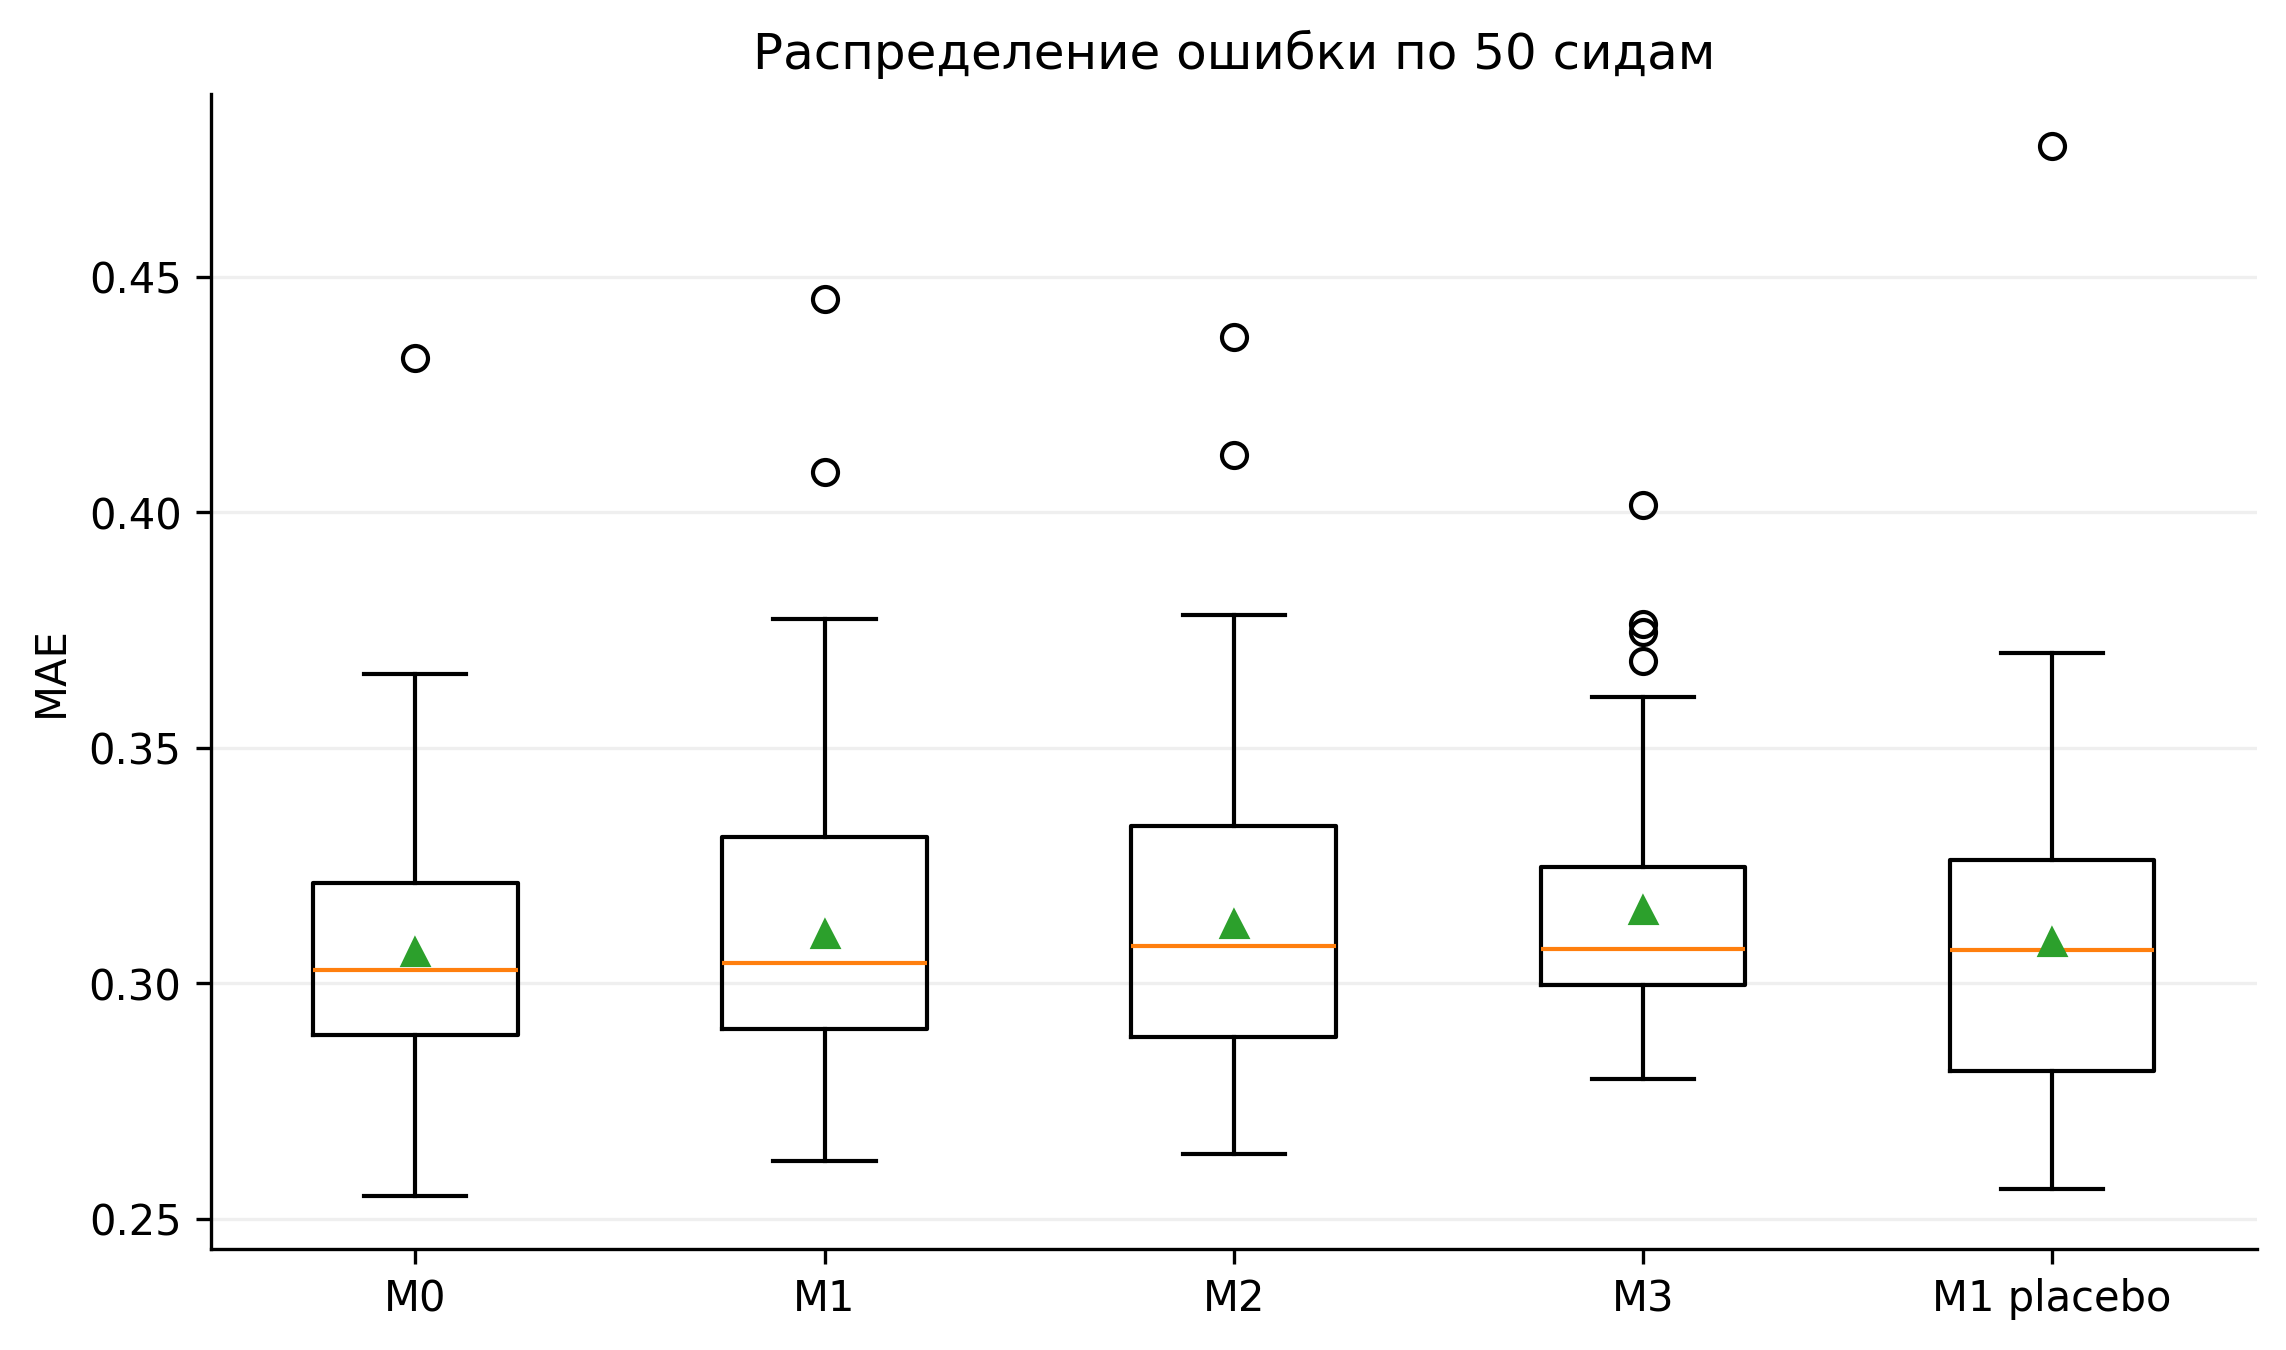

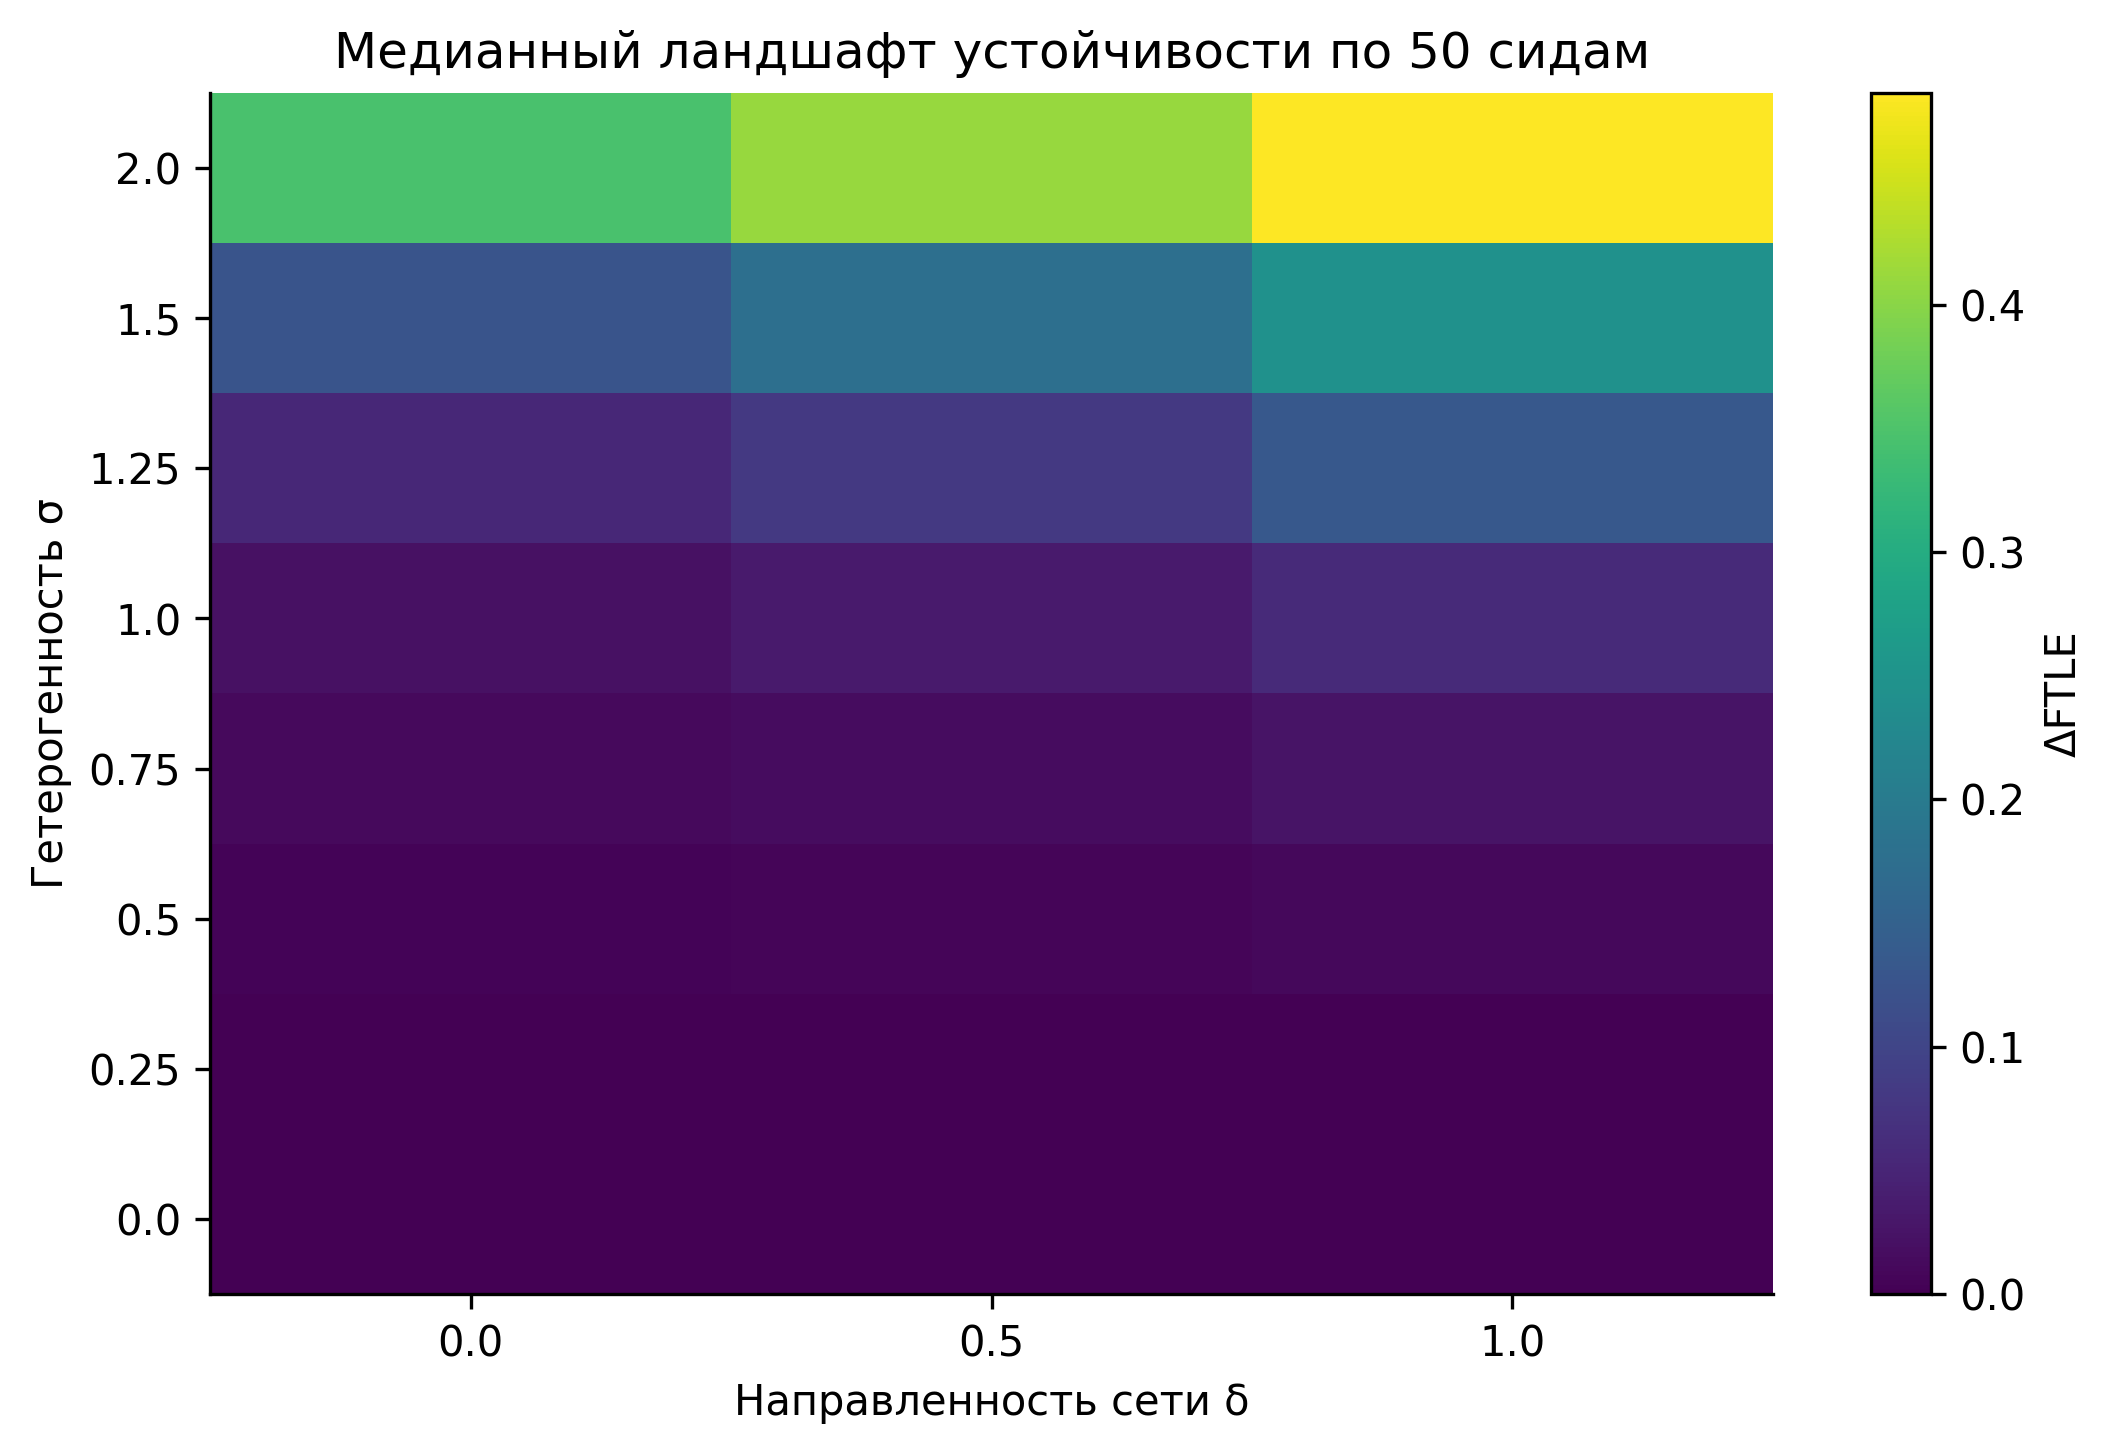

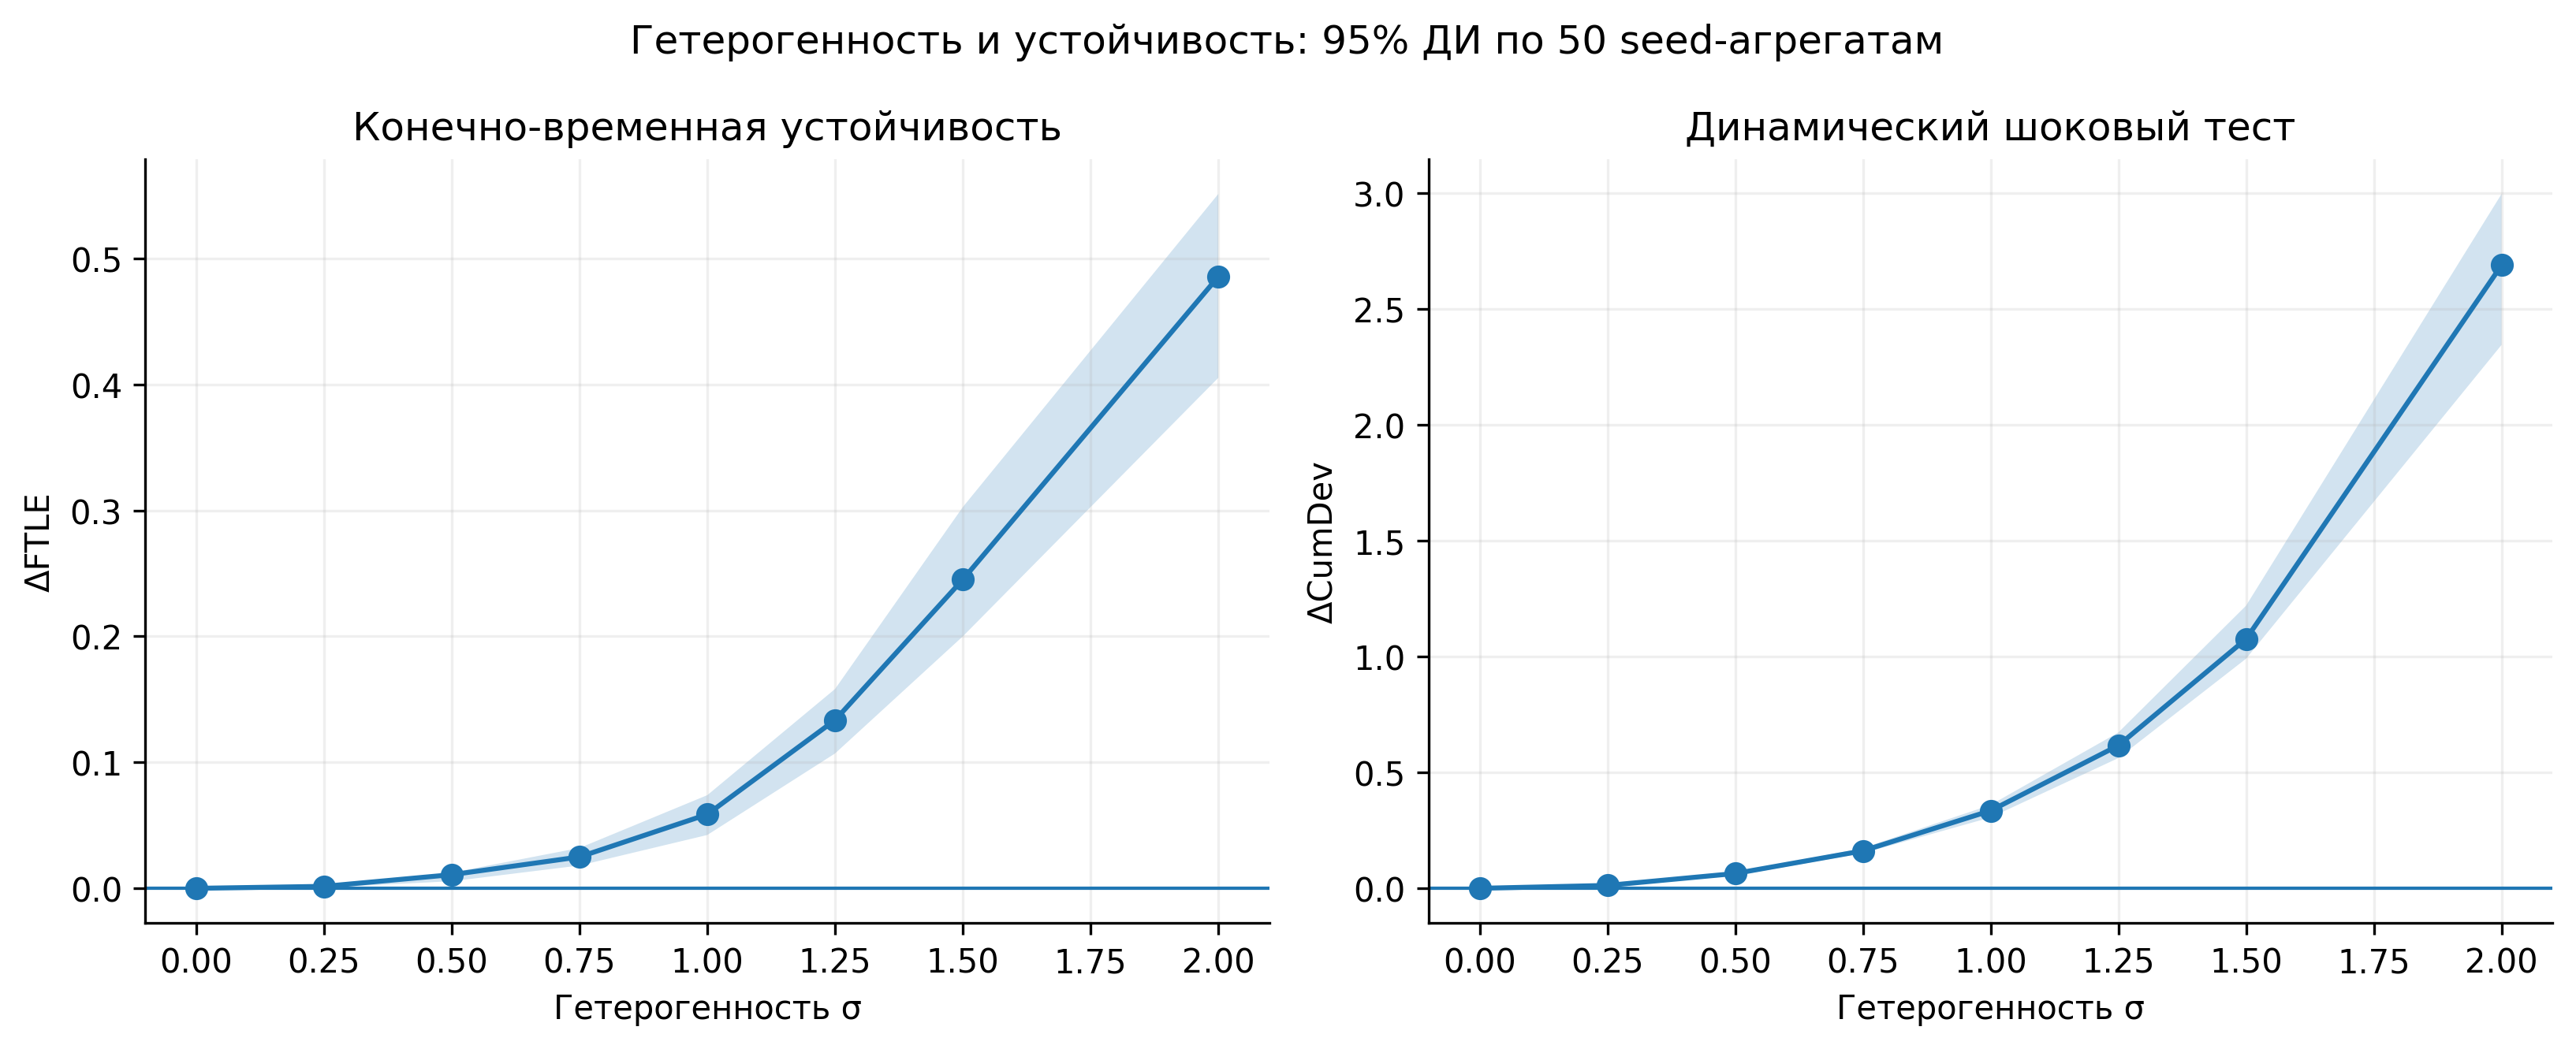

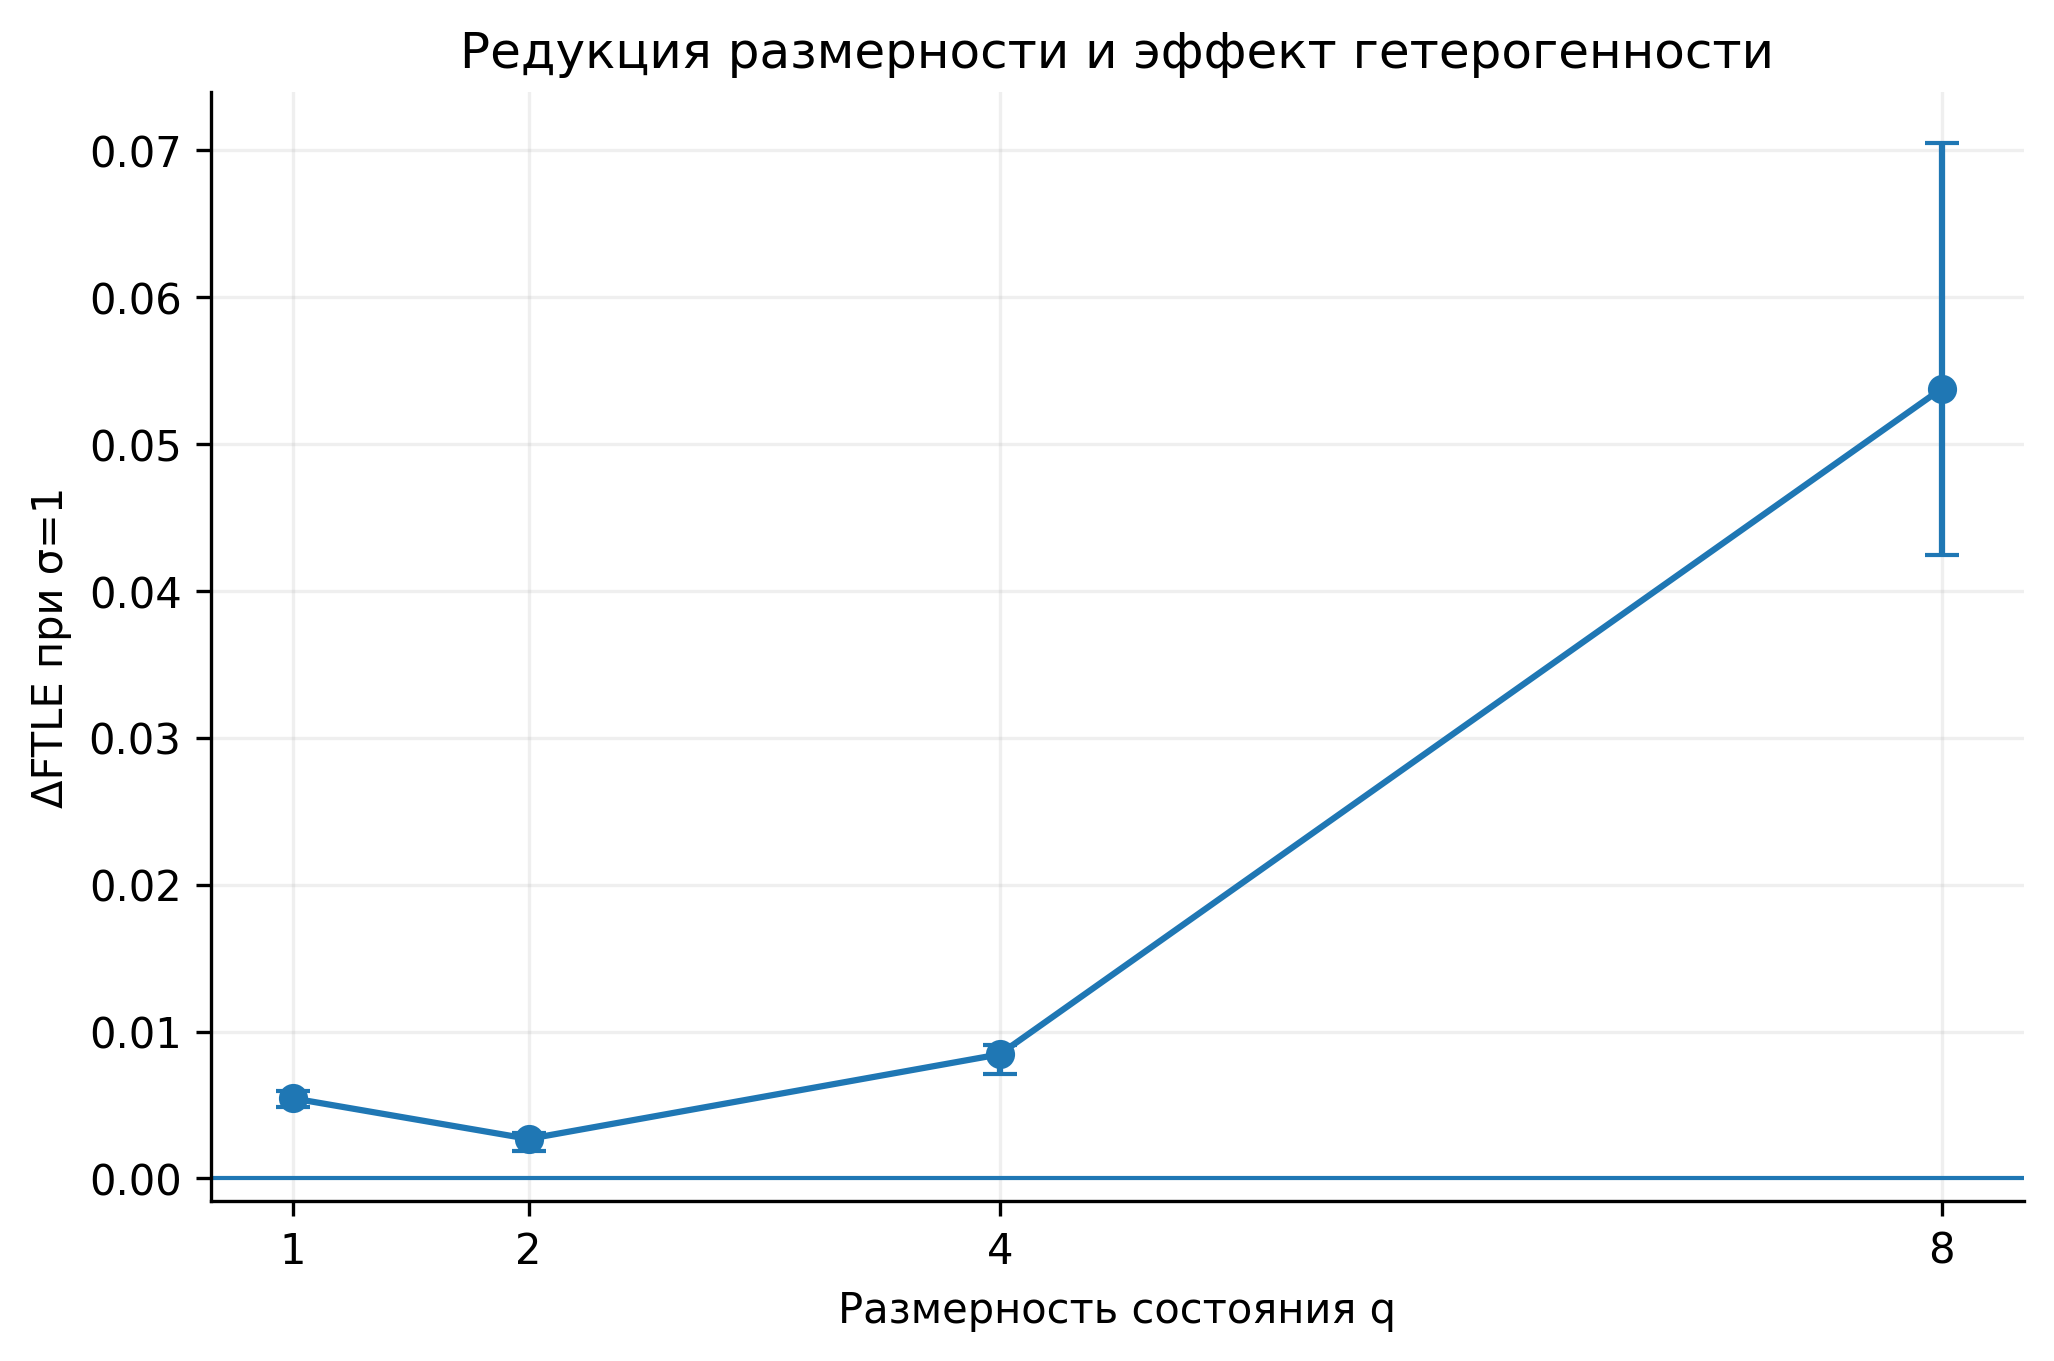

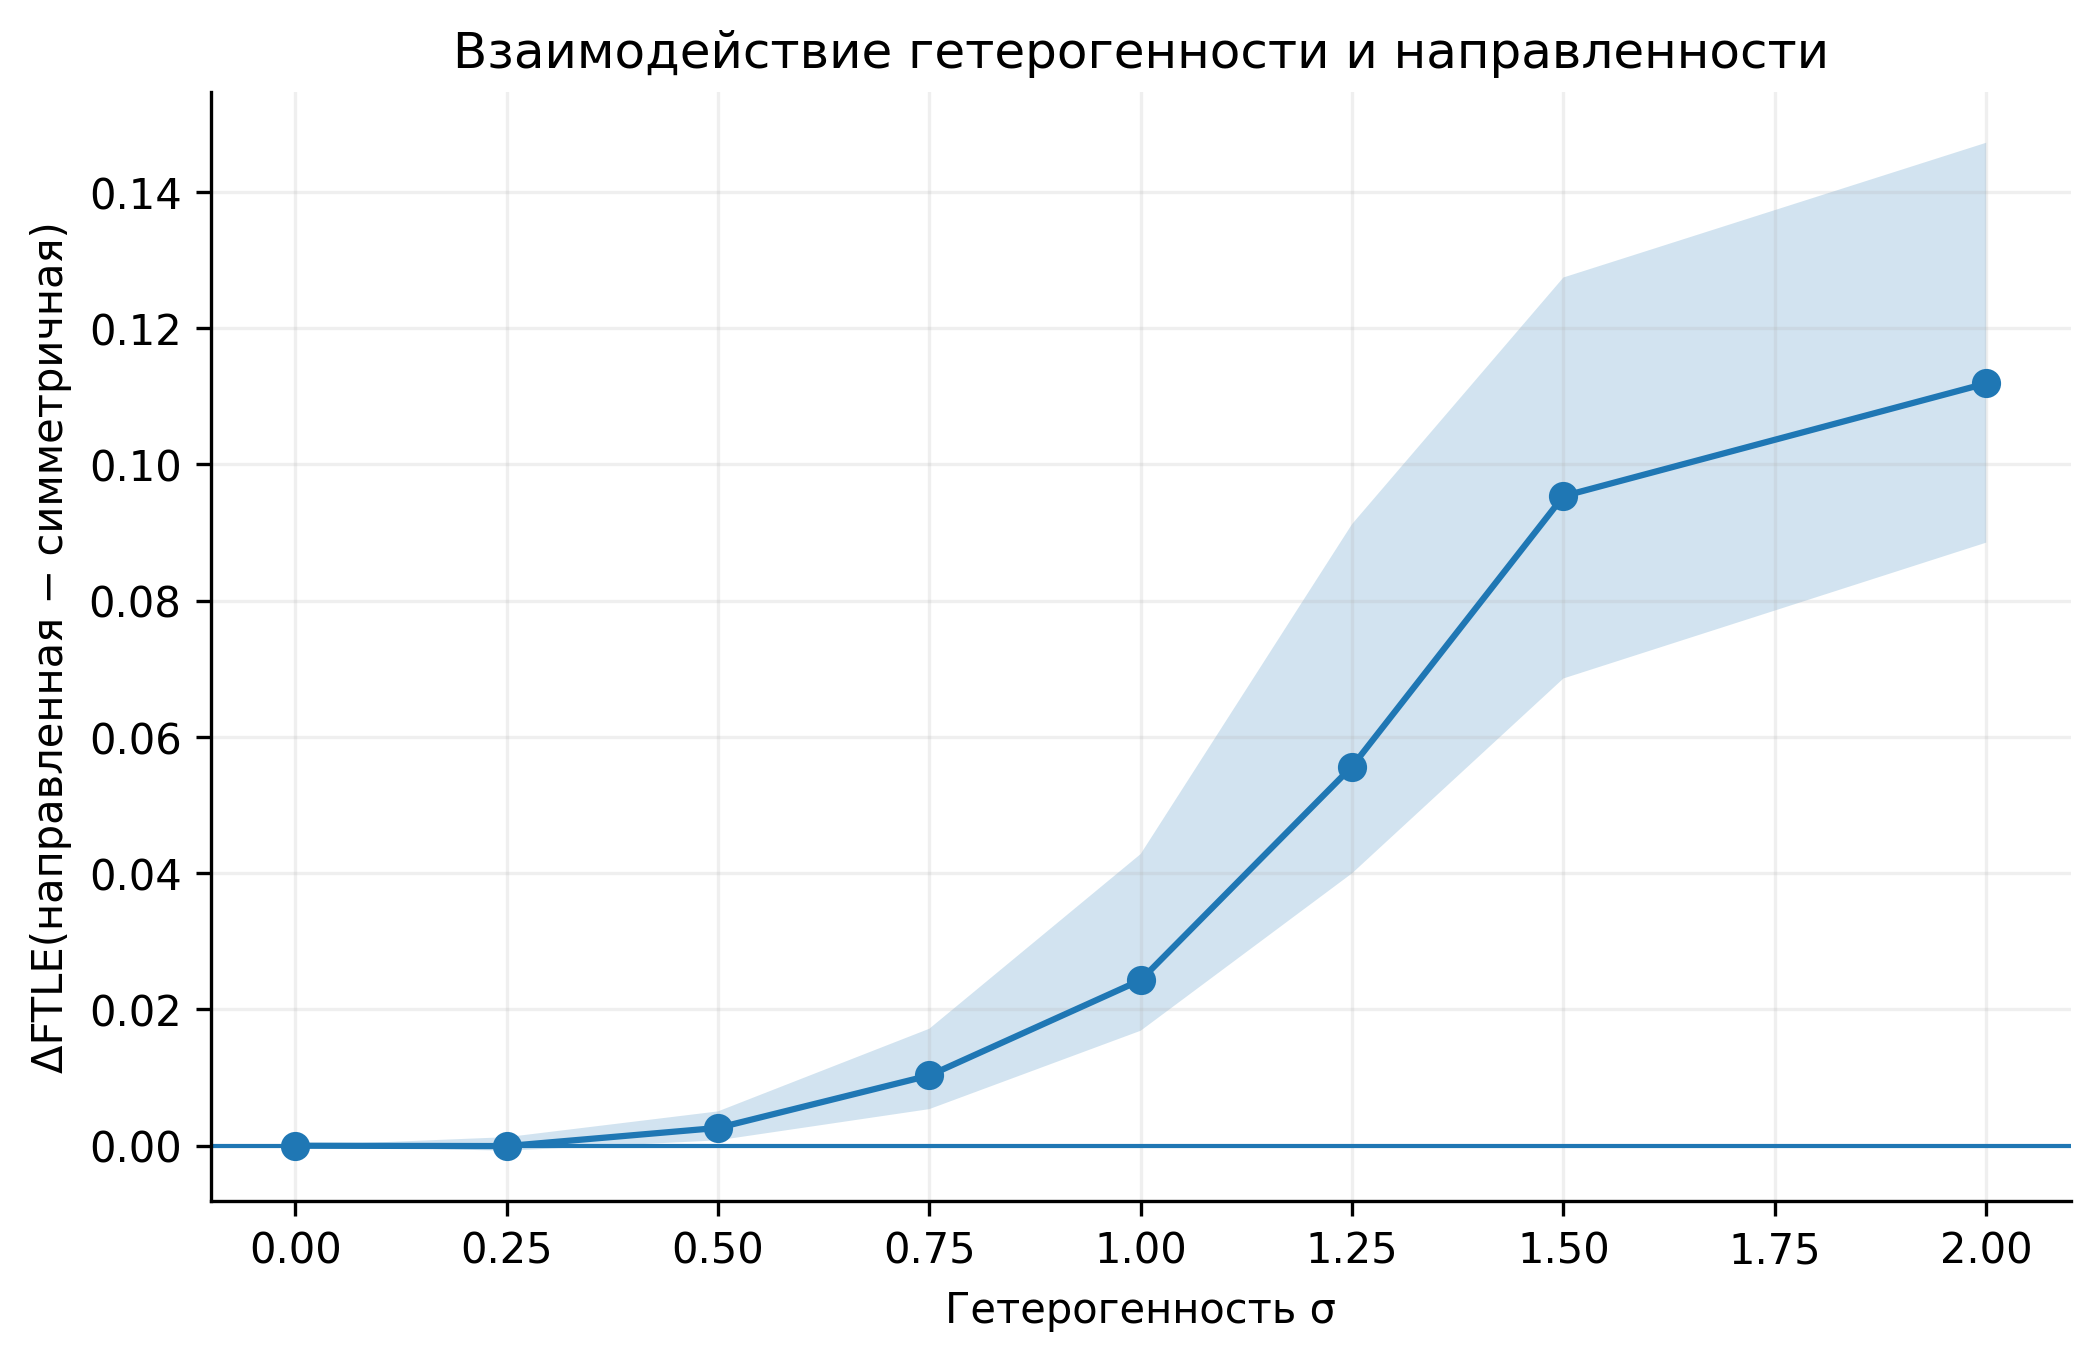

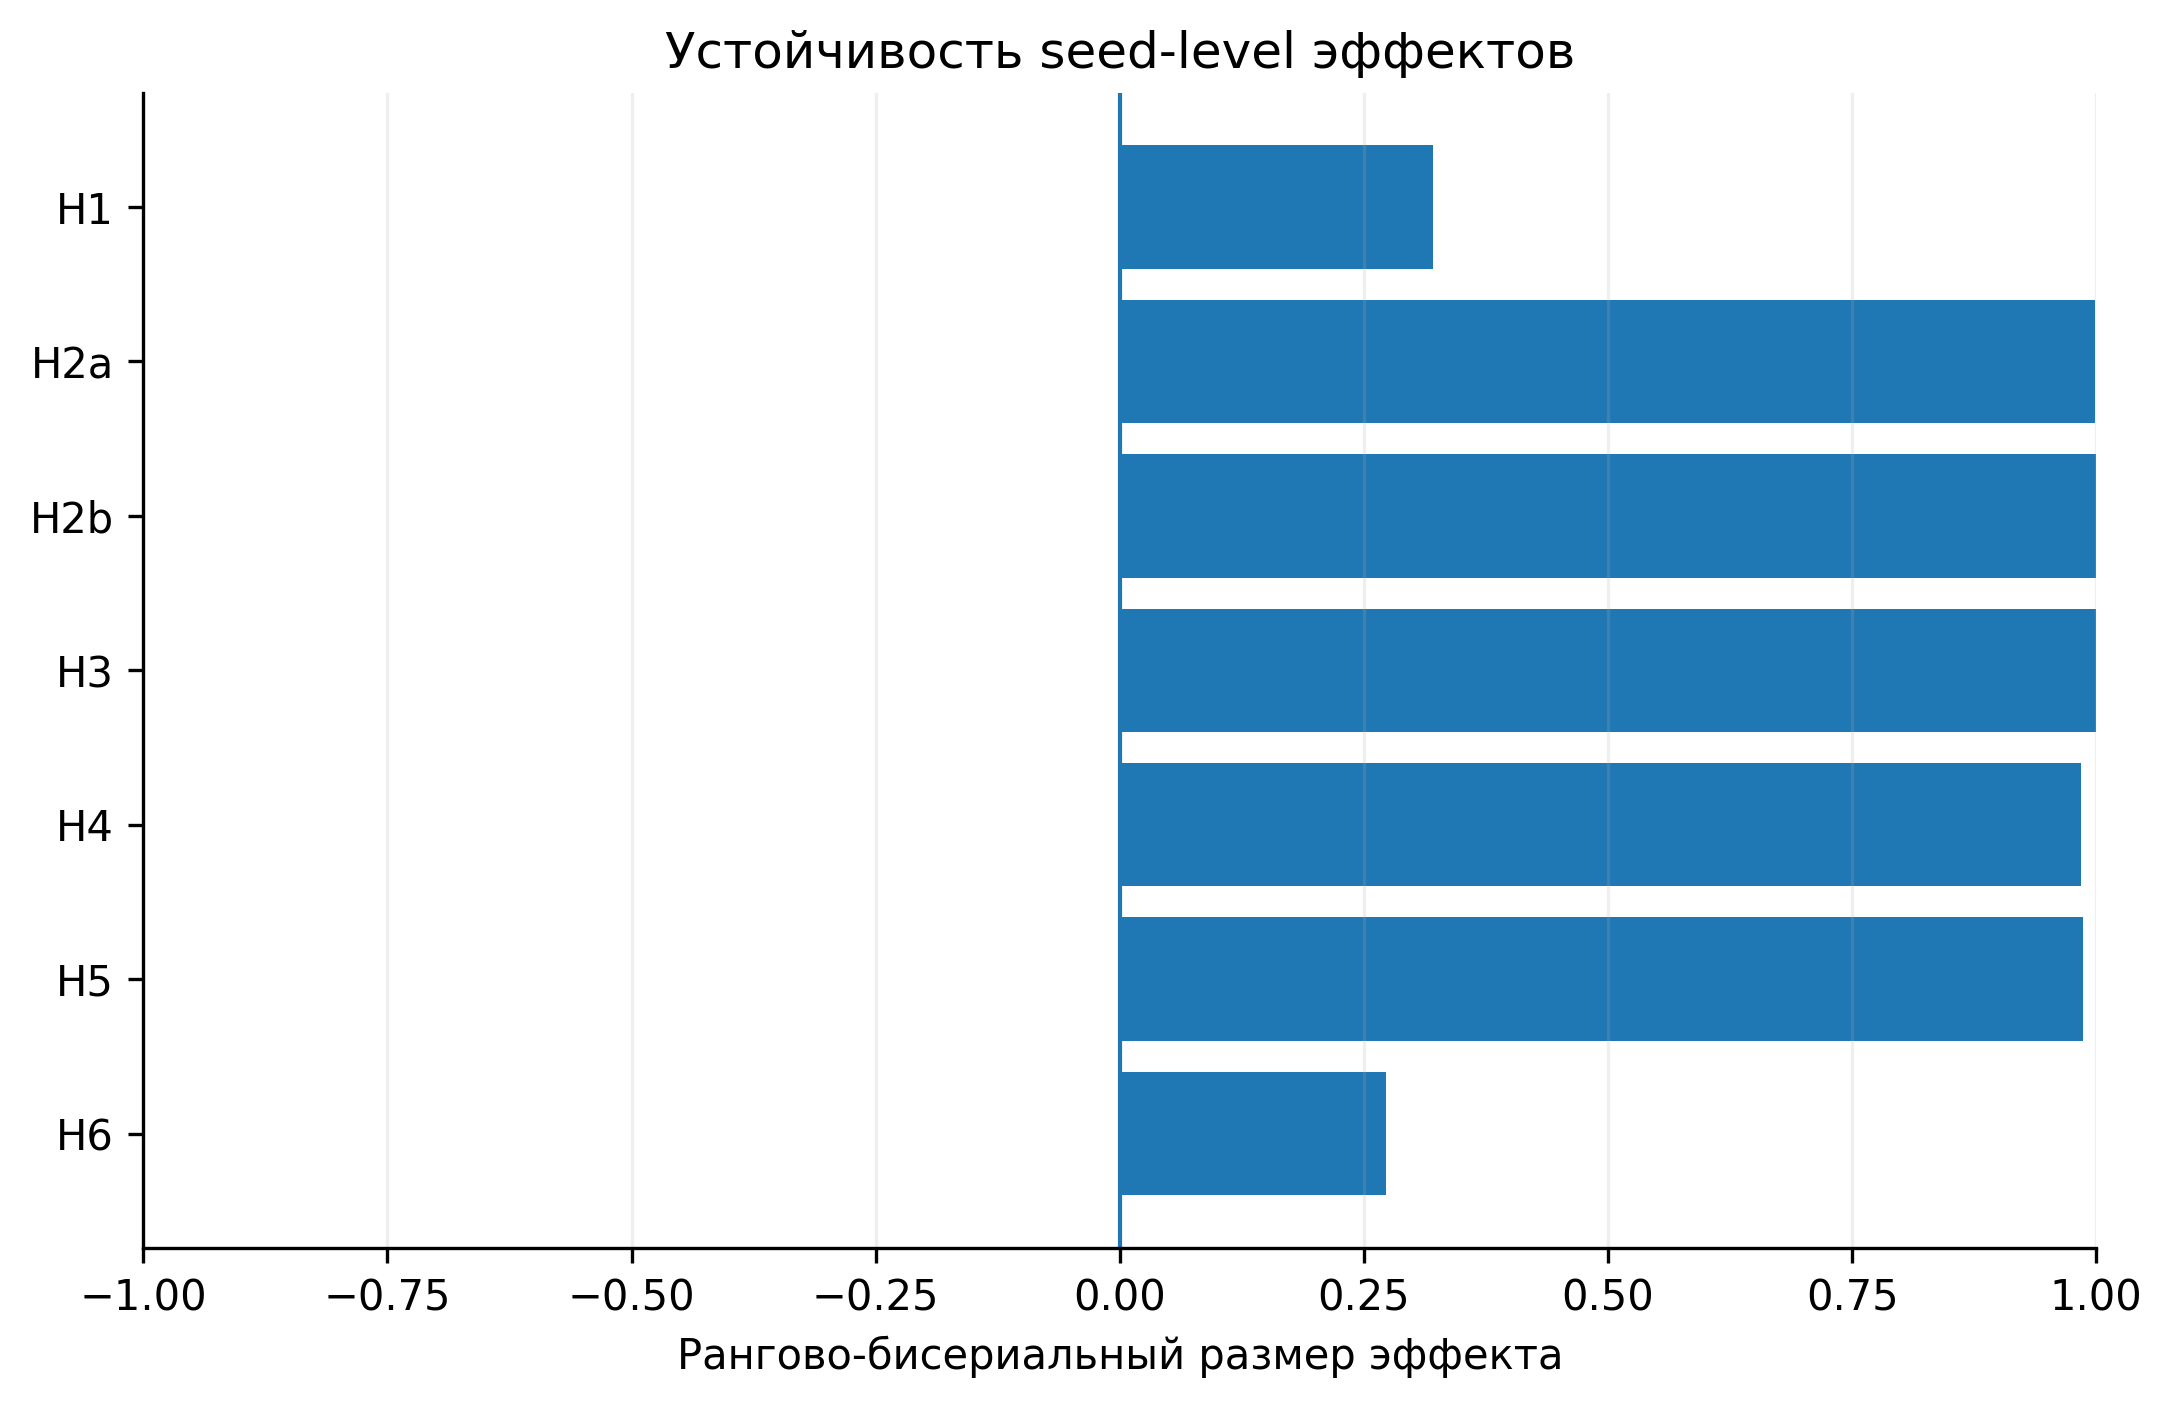

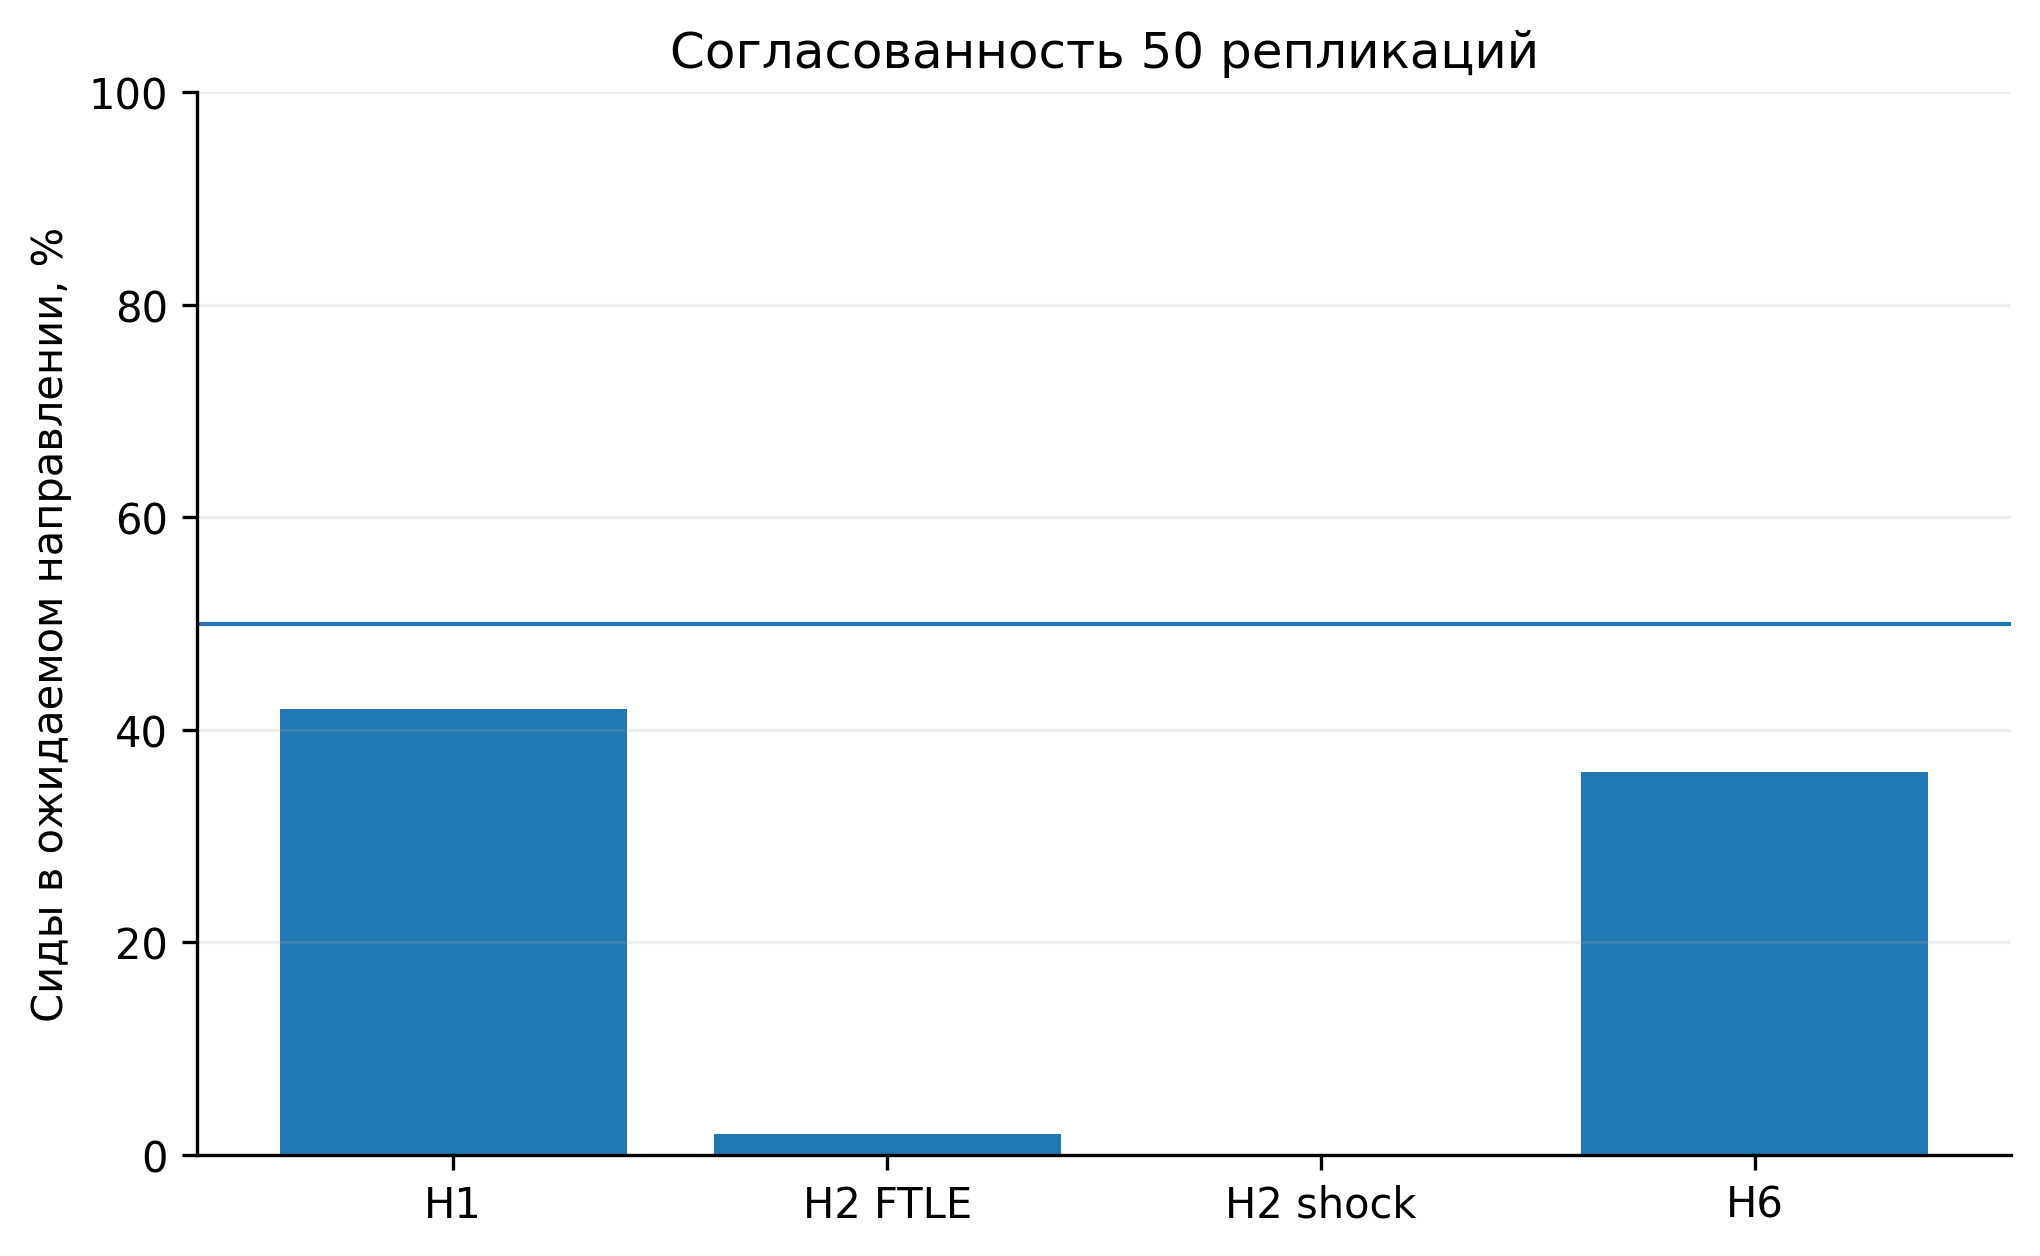

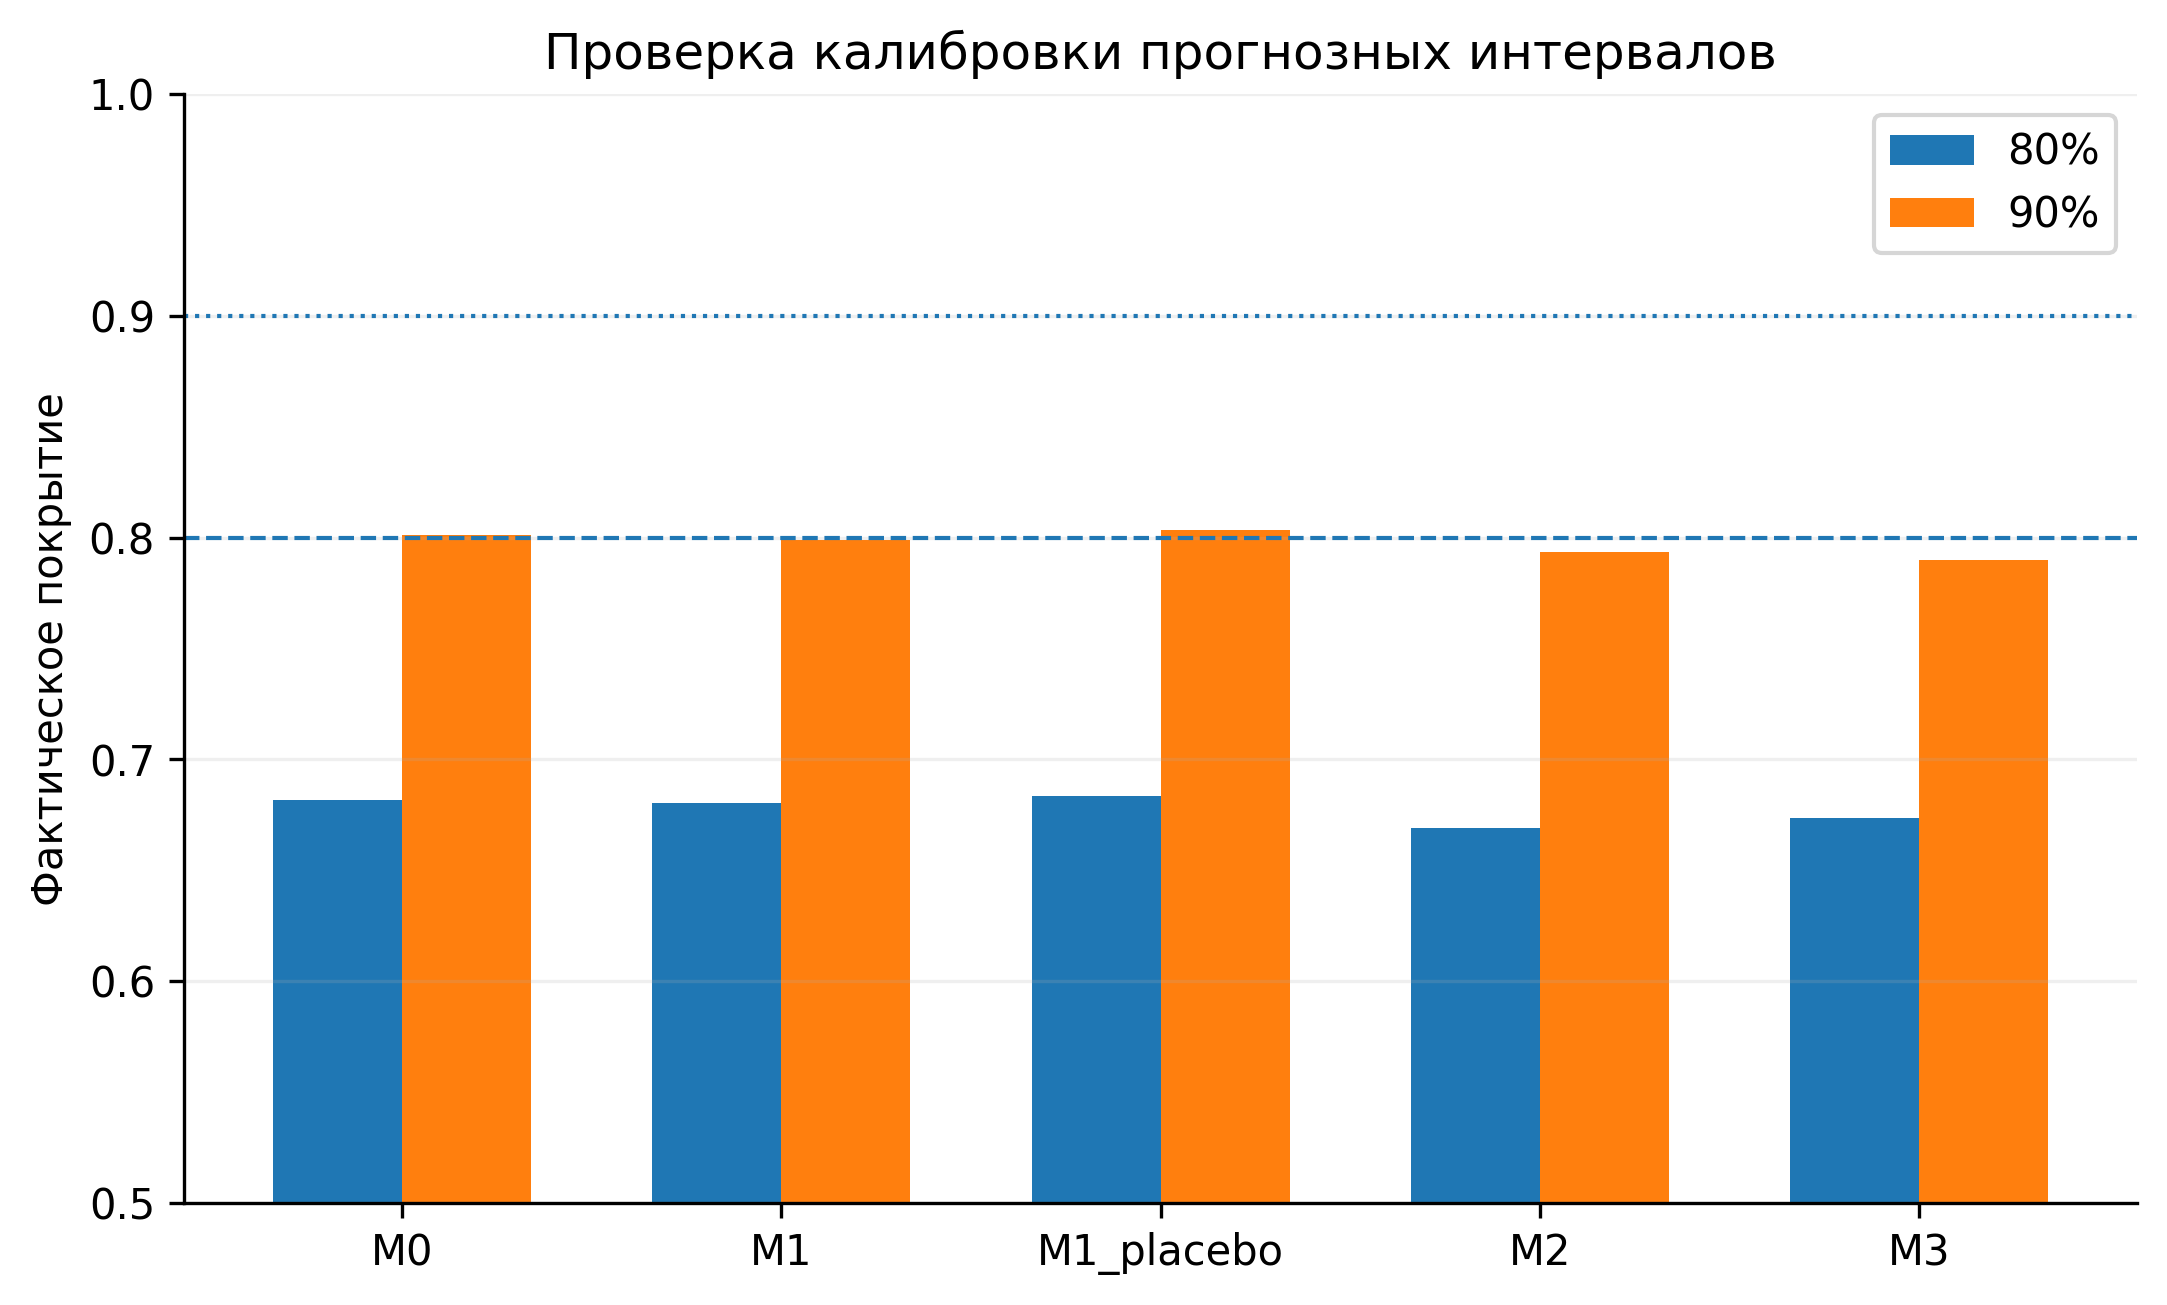

In [8]:
for stem in ["fig01_seed_forecast_mae","fig02_seed_stability_landscape","fig03_heterogeneity_effect","fig04_dimension_effect","fig05_directionality_interaction","fig06_seed_effect_sizes","fig07_seed_consistency","fig08_interval_calibration"]:
    display(Image(filename=str(FIG_RU/f"{stem}_RU.png")))

## 9. Архив и совместимость с GitHub

Ноутбук использует только статические outputs: потоковый текст, HTML/text представление таблиц и Matplotlib PNG. `ipywidgets` и внешнее widget-state не используются. После исполнения `.ipynb` должен полностью отображаться на GitHub.


In [9]:
print(f"Архив результатов: {archive}")
print("GitHub-режим: статические outputs; widgets = False")
print("Технический цикл: conformal calibration + dynamic shock network + seed-level CI audit")
if IN_COLAB:
    from google.colab import files as colab_files
    colab_files.download(str(archive))

Архив результатов: /content/AFM_DPS_50seeds_Foresight_technical_results.zip
GitHub-режим: статические outputs; widgets = False
Технический цикл: conformal calibration + dynamic shock network + seed-level CI audit


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>